# EagleVision Hyperparameter Ablation Notebook  
## Final Kaggle Version: Baseline Setup + Reduced Epochs + Disk-Safe Resume

This notebook is for the **EagleVision deep-learning research project**:

```text
https://github.com/alooboii/EagleVision.git
```

It follows the baseline workflow from your attached `eaglevision2` notebook, but makes the run suitable for hyperparameter ablations on Kaggle T4 by using a reduced training budget and disk-safe logging/checkpoint handling.

Main setup:

```text
Depth mode: metric
Depth profile: hypersim
Depth encoder: vits
Image size: [192, 288]
Split: 90% train / 10% validation
Default loss weights: target_rgb=1.0, cycle_rgb=1.0, target_depth=0.35, cycle_depth=0.35
Default LR: 2e-5
Adapter hidden channels: 32
Default ablation scene limit: 200 scenes
Epochs: 5
Max steps per epoch: 300
```

This final version uses clean progress bars, bounded logs, checkpoint cleanup, and resume logic.


## 0. Global configuration

This is the main cell you modify.

For a quick debug run:

```python
RUN_PROFILE = "smoke"
MAX_ABLATION_RUNS = 3
```

For the final reduced-epoch paper ablation run:

```python
RUN_PROFILE = "paper_reduced"
ABLATION_PRESET = "paper_full"
MAX_ABLATION_RUNS = None
```

This notebook uses your direct Kaggle dataset root:

```text
/kaggle/input/scannet-2d/scannet_2d/
```

That folder already directly contains:

```text
scene0000_00/
  color/
  depth/
  label/
  pose/
```

So no normalization or symlinking is performed.


In [6]:
# =========================
# USER CONFIGURATION
# =========================

from pathlib import Path
import os
import sys
import re
import json
import time
import math
import random
import shutil
import subprocess
from datetime import datetime

REPO_URL = "https://github.com/alooboii/EagleVision.git"
REPO_DIR = Path("/kaggle/working/EagleVision") if Path("/kaggle").exists() else Path.cwd() / "EagleVision"
WORK_DIR = Path("/kaggle/working") if Path("/kaggle").exists() else Path.cwd()
EXPERIMENT_ROOT = WORK_DIR / "eaglevision_ablation_runs"

DIRECT_SCANNET_ROOT = Path("/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d")
USE_DIRECT_DATA_ROOT = True

RAW_DATASET_ROOTS = [
    Path("/kaggle/input"),
    Path("/kaggle/input/scannet-2d"),
    Path("/kaggle/input/scannet-2d/scannet_2d"),
    Path("/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d"),
    Path("/kaggle/input/datasets/klein2111/scannet-2d"),
    Path("/kaggle/input/eaglevision-data"),
    Path.cwd() / "data_inputs",
]

DATA_ROOT = DIRECT_SCANNET_ROOT
NORMALIZED_DATA_ROOT = DATA_ROOT

RUN_PROFILE = "paper_reduced"   # "smoke", "paper_reduced", or "paper_fast"
ABLATION_PRESET = "paper_full"  # "minimal", "paper_core", or "paper_full"

DEVICE = "cuda"
SEED = 7

SCENE_LIMIT = 200
TRAIN_SCENE_FRACTION = 0.90
MIN_COMMON_FRAMES_PER_SCENE = 25

IMAGE_SIZE = [192, 288]
ENCODER = "vits"
DEPTH_MODE = "metric"
DEPTH_PROFILE = "hypersim"
FREEZE_BACKBONE = True
DEFAULT_ADAPTER_HIDDEN_CHANNELS = 32

CHECKPOINT_PATH = REPO_DIR / "baseline" / "depth_anything_v2" / "checkpoints" / "depth_anything_v2_metric_hypersim_vits.pth"
AUTO_FIND_CHECKPOINT = False
ALLOW_NO_CHECKPOINT = False

EPOCHS = 5
MAX_STEPS_PER_EPOCH = 300
MAX_EVAL_BATCHES = 780
BATCH_SIZE = 1
BASE_LR = 2e-5
WEIGHT_DECAY = 1e-4

PAIRING = {
    "min_translation_m": 0.02,
    "max_translation_m": 0.30,
    "min_rotation_deg": 0.8,
    "max_rotation_deg": 8.0,
    "max_index_gap": 10,
    "frame_stride": 2,
    "max_frames_per_scene": 180,
    "max_pairs_per_scene": 120,
}

# Disk-safe output controls
KEEP_ONLY_LATEST_CHECKPOINT = True
DISABLE_VIS_PANELS = True
MAX_LOG_BYTES = 1_000_000
LOG_INTERVAL = 50
CHECKPOINT_INTERVAL = 10**9
VIS_INTERVAL = 10**9

SUBPROCESS_STREAM_MODE = "progress"
PRINT_LOG_TAIL_ON_FAILURE = True
STOP_ON_FIRST_ERROR = False
RESUME_COMPLETED_RUNS = True
RESET_OUTPUT_ROOT = False
MAX_ABLATION_RUNS = None

if RUN_PROFILE == "smoke":
    SCENE_LIMIT = 30
    EPOCHS = 1
    MAX_STEPS_PER_EPOCH = 30
    MAX_EVAL_BATCHES = 50
    MAX_ABLATION_RUNS = 3 if MAX_ABLATION_RUNS is None else MAX_ABLATION_RUNS
    IMAGE_SIZE = [160, 224]
    PAIRING.update({
        "frame_stride": 6,
        "max_frames_per_scene": 60,
        "max_pairs_per_scene": 40,
        "max_index_gap": 8,
    })
elif RUN_PROFILE == "paper_reduced":
    SCENE_LIMIT = 200 if SCENE_LIMIT is None else SCENE_LIMIT
    EPOCHS = 5
    MAX_STEPS_PER_EPOCH = 300
    MAX_EVAL_BATCHES = 780
elif RUN_PROFILE == "paper_fast":
    SCENE_LIMIT = 100 if SCENE_LIMIT is None else SCENE_LIMIT
    EPOCHS = 3
    MAX_STEPS_PER_EPOCH = 200
    MAX_EVAL_BATCHES = 500
else:
    raise ValueError(f"Unknown RUN_PROFILE: {RUN_PROFILE}")

print("Configuration loaded.")
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"RUN_PROFILE: {RUN_PROFILE}")
print(f"ABLATION_PRESET: {ABLATION_PRESET}")
print(f"WORK_DIR: {WORK_DIR}")
print(f"REPO_DIR: {REPO_DIR}")
print(f"EXPERIMENT_ROOT: {EXPERIMENT_ROOT}")
print(f"SCENE_LIMIT: {SCENE_LIMIT}")
print(f"IMAGE_SIZE: {IMAGE_SIZE}")
print(f"EPOCHS: {EPOCHS}")
print(f"MAX_STEPS_PER_EPOCH: {MAX_STEPS_PER_EPOCH}")
print(f"SUBPROCESS_STREAM_MODE: {SUBPROCESS_STREAM_MODE}")


Configuration loaded.
Started: 2026-05-02 06:17:48
RUN_PROFILE: paper_reduced
ABLATION_PRESET: paper_full
WORK_DIR: /kaggle/working
REPO_DIR: /kaggle/working/EagleVision
EXPERIMENT_ROOT: /kaggle/working/eaglevision_ablation_runs
SCENE_LIMIT: 200
IMAGE_SIZE: [192, 288]
EPOCHS: 5
MAX_STEPS_PER_EPOCH: 300
SUBPROCESS_STREAM_MODE: progress


## 1. Helper functions

This cell defines reusable helpers for:

- clean section headers
- shell command execution
- structured logs
- filtered subprocess output
- error-log tails

The full logs are always saved to disk, even when the notebook output is filtered.


In [7]:
# =========================
# HELPERS
# =========================

def print_header(title: str) -> None:
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path

def tail_file(path: Path, n: int = 60) -> str:
    if path is None or not Path(path).exists():
        return ""
    try:
        lines = Path(path).read_text(encoding="utf-8", errors="replace").splitlines()
        return "\n".join(lines[-n:])
    except Exception as exc:
        return f"Could not read log tail: {exc}"

def should_print_subprocess_line(line: str, mode: str, last_print_time: list, min_interval: float = 15.0) -> bool:
    if mode == "silent":
        return False
    if mode == "full":
        return True

    # Filtered mode: keep meaningful progress without spamming notebook output.
    clean = line.strip().replace("\r", "")
    if not clean:
        return False

    always_keywords = [
        "Loading", "Training on", "Evaluating on", "Built train", "Built val",
        "Built evaluation", "Starting", "Using max_batches", "Writing outputs",
        "loss_", "target_rgb_l1", "cycle_rgb_l1", "reproj", "Traceback",
        "Error", "RuntimeError", "Exception", "Finished", "checkpoint",
    ]
    if any(k in clean for k in always_keywords):
        return True

    # Periodically show tqdm-style epoch/eval lines.
    now = time.time()
    if ("epoch" in clean.lower() or "eval" in clean.lower()) and (now - last_print_time[0] > min_interval):
        last_print_time[0] = now
        return True

    return False

def run_cmd(cmd, cwd=None, log_path=None, stream_mode="progress", check=True, env=None):
    """Run a shell command with clean progress and bounded disk logging."""
    import shlex
    import subprocess
    import time
    import os
    import re
    import errno
    from tqdm.auto import tqdm

    start_time = time.time()
    cwd = Path(cwd) if cwd is not None else None

    if log_path is not None:
        log_path = Path(log_path)
        ensure_dir(log_path.parent)

    merged_env = os.environ.copy()
    if env:
        merged_env.update(env)

    command_str = " ".join(shlex.quote(str(x)) for x in cmd)
    print(f"[cmd] {command_str}")
    if cwd:
        print(f"[cwd] {cwd}")
    if log_path:
        print(f"[log] {log_path}")

    progress_regex = re.compile(r"(?P<cur>\d+)\s*/\s*(?P<total>\d+)")
    metric_regex = re.compile(
        r"(target_rgb_l1|cycle_rgb_l1|psnr|ssim|reprojection_depth|depth_l1|rmse|abs_rel|loss(?:_[A-Za-z0-9_]+)?)=(-?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)"
    )

    stdout_tail = ""
    max_stdout_chars = 2_000_000
    pbar = None
    pbar_total = None
    last_update_time = 0.0
    last_metric_summary = ""
    last_logged_progress_time = 0.0
    log_bytes_written = 0
    log_disabled = False
    log_truncated_notice_written = False

    def append_stdout_tail(s):
        nonlocal stdout_tail
        stdout_tail += s
        if len(stdout_tail) > max_stdout_chars:
            stdout_tail = stdout_tail[-max_stdout_chars:]

    def is_tqdm_like(clean):
        return bool(progress_regex.search(clean)) and ("|" in clean or "it/s" in clean or "s/it" in clean)

    def should_log_piece(clean):
        nonlocal last_logged_progress_time
        if not clean:
            return False
        if is_tqdm_like(clean):
            now = time.time()
            if now - last_logged_progress_time >= 15:
                last_logged_progress_time = now
                return True
            return False
        return True

    def safe_log_write(log_f, text_to_write):
        nonlocal log_bytes_written, log_disabled, log_truncated_notice_written
        if log_f is None or log_disabled:
            return
        try:
            encoded_len = len(text_to_write.encode("utf-8", errors="replace"))
            if log_bytes_written + encoded_len > MAX_LOG_BYTES:
                if not log_truncated_notice_written:
                    notice = "\n...[log truncated by notebook to save Kaggle disk; raw subprocess spam suppressed]...\n"
                    log_f.write(notice)
                    log_bytes_written += len(notice.encode("utf-8"))
                    log_truncated_notice_written = True
                return
            log_f.write(text_to_write)
            log_bytes_written += encoded_len
        except OSError as exc:
            if getattr(exc, "errno", None) == errno.ENOSPC:
                log_disabled = True
                print("[warning] disk is full while writing log; disabling further log writes for this command")
            else:
                raise

    def handle_piece(piece):
        nonlocal pbar, pbar_total, last_update_time, last_metric_summary
        clean = piece.strip()
        if not clean:
            return

        if stream_mode == "full":
            print(clean)
            return
        if stream_mode == "silent":
            return

        if stream_mode == "filtered":
            selected = (
                clean.startswith("[") or clean.startswith("Epoch") or clean.startswith("epoch")
                or clean.startswith("Saved") or clean.startswith("Using") or clean.startswith("Starting")
                or clean.startswith("Completed") or "ERROR" in clean or "Traceback" in clean
                or "RuntimeError" in clean or "FileNotFoundError" in clean or "ModuleNotFoundError" in clean
            )
            metric_line = "target_rgb_l1" in clean or "cycle_rgb_l1" in clean or "reprojection_depth" in clean
            if (selected or metric_line) and not is_tqdm_like(clean):
                print(clean)
            return

        if stream_mode == "progress":
            is_error = (
                "Traceback" in clean or "RuntimeError" in clean or "FileNotFoundError" in clean
                or "ModuleNotFoundError" in clean or clean.startswith("ERROR")
            )
            if is_error:
                print(clean)
                return

            matches = list(progress_regex.finditer(clean))
            if matches:
                m = matches[-1]
                cur = int(m.group("cur"))
                total = int(m.group("total"))
                if total > 0:
                    if pbar is None or pbar_total != total:
                        if pbar is not None:
                            pbar.close()
                        desc = "subprocess"
                        lower = clean.lower()
                        if "eval" in lower:
                            desc = "eval"
                        elif "train" in lower or "epoch" in lower:
                            desc = "train"
                        elif "download" in lower:
                            desc = "download"
                        pbar = tqdm(total=total, desc=desc, leave=True)
                        pbar_total = total

                    cur = min(cur, total)
                    if cur >= pbar.n:
                        pbar.update(cur - pbar.n)

                    metrics = metric_regex.findall(clean)
                    if metrics:
                        keep = []
                        for k, v in metrics[:3]:
                            try:
                                keep.append(f"{k}={float(v):.4f}")
                            except Exception:
                                keep.append(f"{k}={v}")
                        last_metric_summary = " ".join(keep)

                    now = time.time()
                    if last_metric_summary and now - last_update_time > 0.5:
                        pbar.set_postfix_str(last_metric_summary)
                        last_update_time = now
                return

            status_prefixes = ("Starting ", "Using ", "Saved ", "Completed ", "Loaded ", "Downloading ", "Checkpoint ", "Loading ", "Training ")
            if clean.startswith(status_prefixes):
                print(clean)
            return

    log_f = None
    try:
        if log_path is not None:
            log_f = open(log_path, "w", encoding="utf-8", errors="replace")

        with subprocess.Popen(
            [str(x) for x in cmd],
            cwd=str(cwd) if cwd else None,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
            env=merged_env,
        ) as proc:
            for raw_line in proc.stdout:
                append_stdout_tail(raw_line)
                pieces = re.split(r"[\r\n]+", raw_line)
                useful_for_log = []
                for piece in pieces:
                    handle_piece(piece)
                    clean = piece.strip()
                    if should_log_piece(clean):
                        useful_for_log.append(piece)

                if useful_for_log:
                    safe_log_write(log_f, "\n".join(useful_for_log) + "\n")

            return_code = proc.wait()
    finally:
        if pbar is not None:
            pbar.close()
        if log_f:
            try:
                log_f.close()
            except OSError:
                pass

    elapsed = time.time() - start_time
    print(f"[done] return_code={return_code} elapsed={elapsed:.1f}s")

    result = {
        "return_code": return_code,
        "elapsed_sec": elapsed,
        "stdout": stdout_tail,
        "log_path": str(log_path) if log_path else None,
        "cmd": command_str,
    }

    if check and return_code != 0:
        raise RuntimeError(f"Command failed with return code {return_code}. See log: {log_path}")

    return result

def ensure_package(package_name: str, import_name: str | None = None):
    import_name = import_name or package_name
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing missing package: {package_name}")
        run_cmd([sys.executable, "-m", "pip", "install", "-q", package_name],
                stream_mode="filtered",
                check=True)

print_header("Environment check")
print(f"Python: {sys.version}")

try:
    import torch
    print(f"PyTorch: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    if DEVICE == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("DEVICE='cuda' but CUDA is unavailable. Enable Kaggle GPU or set DEVICE='cpu'.")
except ImportError:
    print("PyTorch is not importable yet. It should be available after installing the repo dependencies.")

if RESET_OUTPUT_ROOT and EXPERIMENT_ROOT.exists():
    print(f"Resetting output root: {EXPERIMENT_ROOT}")
    shutil.rmtree(EXPERIMENT_ROOT)

ensure_dir(EXPERIMENT_ROOT)
ensure_dir(EXPERIMENT_ROOT / "logs")
ensure_dir(EXPERIMENT_ROOT / "configs")
ensure_dir(EXPERIMENT_ROOT / "metrics")
ensure_dir(EXPERIMENT_ROOT / "runs")


print("Helper setup complete.")


def cleanup_run_artifacts(run_dir: Path, keep_latest_checkpoint=True, remove_panels=True):
    run_dir = Path(run_dir)
    if remove_panels:
        for panels_dir in [run_dir / "panels", run_dir / "visualizations"]:
            if panels_dir.exists():
                shutil.rmtree(panels_dir, ignore_errors=True)

    if keep_latest_checkpoint:
        ckpt_dir = run_dir / "checkpoints"
        if ckpt_dir.exists():
            checkpoints = sorted(ckpt_dir.glob("*.pt"), key=lambda p: p.stat().st_mtime)
            for old_ckpt in checkpoints[:-1]:
                try:
                    old_ckpt.unlink()
                except OSError:
                    pass

def cleanup_global_artifacts():
    if not EXPERIMENT_ROOT.exists():
        return
    runs_dir = EXPERIMENT_ROOT / "runs"
    if runs_dir.exists():
        for run_dir in runs_dir.iterdir():
            if run_dir.is_dir():
                cleanup_run_artifacts(
                    run_dir,
                    keep_latest_checkpoint=KEEP_ONLY_LATEST_CHECKPOINT,
                    remove_panels=DISABLE_VIS_PANELS,
                )
    for cache_dir in WORK_DIR.rglob("__pycache__"):
        try:
            shutil.rmtree(cache_dir, ignore_errors=True)
        except Exception:
            pass



Environment check
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Helper setup complete.


## 2. Clone EagleVision and install it

This notebook clones the project repo directly, so it does not depend on local files.

Important import detail:

- `eaglevision` lives in `EagleVision/src`
- the vendor `baseline/` package lives in the repo root

Therefore the notebook adds **both** paths to `PYTHONPATH`. This prevents the common:

```text
ModuleNotFoundError: No module named 'baseline'
```


In [8]:
# =========================
# CLONE AND INSTALL REPO
# =========================

print_header("Cloning EagleVision repository")

if REPO_DIR.exists() and (REPO_DIR / ".git").exists():
    print("Repo already exists. Pulling latest main branch if possible.")
    run_cmd(["git", "-C", str(REPO_DIR), "pull", "--ff-only"],
            log_path=EXPERIMENT_ROOT / "logs" / "git_pull.log",
            stream_mode="filtered",
            check=False)
else:
    if REPO_DIR.exists():
        print(f"Removing existing non-git directory: {REPO_DIR}")
        shutil.rmtree(REPO_DIR)
    run_cmd(["git", "clone", REPO_URL, str(REPO_DIR)],
            log_path=EXPERIMENT_ROOT / "logs" / "git_clone.log",
            stream_mode="filtered",
            check=True)

print_header("Installing EagleVision in editable mode")
run_cmd([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR) + "[dev]"],
        log_path=EXPERIMENT_ROOT / "logs" / "pip_install_repo.log",
        stream_mode="filtered",
        check=True)

# Add both repo root and src to import paths.
repo_root_path = str(REPO_DIR)
src_path = str(REPO_DIR / "src")

for path_to_add in [repo_root_path, src_path]:
    if path_to_add not in sys.path:
        sys.path.insert(0, path_to_add)

existing_pythonpath = os.environ.get("PYTHONPATH", "")
pythonpath_parts = [repo_root_path, src_path]
if existing_pythonpath:
    pythonpath_parts.append(existing_pythonpath)
os.environ["PYTHONPATH"] = os.pathsep.join(pythonpath_parts)

print("Python paths patched:")
print(f"  repo root: {repo_root_path}")
print(f"  src path:  {src_path}")

# General notebook packages
ensure_package("pandas")
ensure_package("pyyaml", "yaml")
ensure_package("tqdm")
ensure_package("matplotlib")
ensure_package("openpyxl")

print("Repo installation complete.")



Cloning EagleVision repository
Repo already exists. Pulling latest main branch if possible.
[cmd] git -C /kaggle/working/EagleVision pull --ff-only
[log] /kaggle/working/eaglevision_ablation_runs/logs/git_pull.log
[done] return_code=0 elapsed=0.2s

Installing EagleVision in editable mode
[cmd] /usr/bin/python3 -m pip install -q -e '/kaggle/working/EagleVision[dev]'
[log] /kaggle/working/eaglevision_ablation_runs/logs/pip_install_repo.log
[done] return_code=0 elapsed=8.4s
Python paths patched:
  repo root: /kaggle/working/EagleVision
  src path:  /kaggle/working/EagleVision/src
Repo installation complete.


## 3. Download the baseline checkpoint using the attached notebook workflow

This cell follows the same baseline-checkpoint logic as your attached `eaglevision2` notebook.

That notebook downloads checkpoints using:

```bash
python -m baseline.depth_anything_v2 download \
  --mode all \
  --profile hypersim \
  --encoder vits
```

Then it resolves the metric Hypersim ViT-S checkpoint:

```text
baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth
```

This version keeps that workflow, but adds:

- no recursive `/kaggle/input` checkpoint search;
- explicit file existence checks;
- clear logs;
- exact `CHECKPOINT_PATH` injection into every generated EagleVision config.

Make sure Kaggle internet is enabled before running this cell.


In [9]:
# =========================
# CHECKPOINT SETUP - ATTACHED BASELINE NOTEBOOK WORKFLOW
# =========================

print_header("Checkpoint setup using attached baseline workflow")

# Do not recursively search /kaggle/input.
# Your ScanNet dataset has thousands of files, so checkpoint search there is unnecessarily slow.
AUTO_FIND_CHECKPOINT = False
ALLOW_NO_CHECKPOINT = False

checkpoint_dir = REPO_DIR / "baseline" / "depth_anything_v2" / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Same command style as your attached eaglevision2 notebook:
# python -m baseline.depth_anything_v2 download --mode all --profile hypersim --encoder vits
print("[status] downloading Depth Anything V2 baseline checkpoints for vits using repo CLI")
print("[status] this uses the same workflow as the attached eaglevision2 notebook")
print("[status] if the files already exist, the downloader should skip/reuse them depending on repo logic")

run_cmd(
    [
        sys.executable, "-u", "-m", "baseline.depth_anything_v2", "download",
        "--mode", "all",
        "--profile", DEPTH_PROFILE,
        "--encoder", ENCODER,
    ],
    cwd=REPO_DIR,
    log_path=EXPERIMENT_ROOT / "logs" / "download_depth_anything_checkpoint.log",
    stream_mode="filtered",
    check=True,
    env={
        "PYTHONPATH": os.pathsep.join([
            str(REPO_DIR),
            str(REPO_DIR / "src"),
            os.environ.get("PYTHONPATH", ""),
        ])
    },
)

# Resolve pretrained checkpoint according to selected mode, same idea as attached notebook.
if DEPTH_MODE == "metric":
    ckpt_name = f"depth_anything_v2_metric_{DEPTH_PROFILE}_{ENCODER}.pth"
else:
    ckpt_name = f"depth_anything_v2_{ENCODER}.pth"

DEFAULT_DEPTH_CKPT = checkpoint_dir / ckpt_name

print("checkpoint dir:", checkpoint_dir)
checkpoint_files = sorted(checkpoint_dir.glob("*.pth"))
print(f"checkpoint files found: {len(checkpoint_files)}")
for p in checkpoint_files:
    size_mb = p.stat().st_size / (1024 ** 2)
    print(f"  - {p.name} ({size_mb:.2f} MB)")

if not checkpoint_files:
    raise RuntimeError(
        f"No checkpoint file found after download in {checkpoint_dir}. "
        "Check that Kaggle internet is ON and inspect logs/download_depth_anything_checkpoint.log."
    )

if not DEFAULT_DEPTH_CKPT.exists():
    raise FileNotFoundError(
        f"Missing expected pretrained DA-V2 checkpoint: {DEFAULT_DEPTH_CKPT}. "
        f"Available checkpoint files: {[p.name for p in checkpoint_files]}"
    )

CHECKPOINT_PATH = str(DEFAULT_DEPTH_CKPT)
size_mb = DEFAULT_DEPTH_CKPT.stat().st_size / (1024 ** 2)

print("Using baseline checkpoint:")
print(CHECKPOINT_PATH)
print(f"Checkpoint size: {size_mb:.2f} MB")



Checkpoint setup using attached baseline workflow
[status] downloading Depth Anything V2 baseline checkpoints for vits using repo CLI
[status] this uses the same workflow as the attached eaglevision2 notebook
[status] if the files already exist, the downloader should skip/reuse them depending on repo logic
[cmd] /usr/bin/python3 -u -m baseline.depth_anything_v2 download --mode all --profile hypersim --encoder vits
[cwd] /kaggle/working/EagleVision
[log] /kaggle/working/eaglevision_ablation_runs/logs/download_depth_anything_checkpoint.log
[done] return_code=0 elapsed=0.1s
checkpoint dir: /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints
checkpoint files found: 2
  - depth_anything_v2_metric_hypersim_vits.pth (94.63 MB)
  - depth_anything_v2_vits.pth (94.62 MB)
Using baseline checkpoint:
/kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth
Checkpoint size: 94.63 MB


### Why this checkpoint cell matters

The ablation runs are still performed through EagleVision's train/eval scripts, not through standalone baseline inference. The baseline downloader is used only to obtain the pretrained Depth Anything V2 weights. Those weights are then passed into the EagleVision model config for:

- `baseline_only` evaluation;
- adapted model training;
- every hyperparameter ablation.


## 4. Use the direct ScanNet-style dataset root

Your Kaggle dataset is already in the correct layout:

```text
/kaggle/input/scannet-2d/scannet_2d/
  scene0000_00/
    color/
    depth/
    label/
    pose/
```

The repo expects the data root to directly contain scene folders. Therefore, this notebook uses `/kaggle/input/scannet-2d/scannet_2d` directly and does **not** create a normalized/symlinked copy.

If that exact path is not found, the notebook falls back to recursively searching the configured input roots.


In [10]:
# =========================
# FAST DATA ROOT SELECTION
# =========================

print_header("Selecting data root")

DATA_ROOT = Path("/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d")
NORMALIZED_DATA_ROOT = DATA_ROOT

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"DATA_ROOT does not exist: {DATA_ROOT}")

scene_like_dirs = sorted([
    p for p in DATA_ROOT.iterdir()
    if p.is_dir()
    and (p / "color").exists()
    and (p / "depth").exists()
    and (p / "pose").exists()
], key=lambda p: p.name)

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"Scene folders found: {len(scene_like_dirs)}")

if len(scene_like_dirs) < 2:
    raise RuntimeError(
        "DATA_ROOT exists but does not look like ScanNet 2D. "
        "Expected scene folders containing color/, depth/, and pose/."
    )

print("First scene folders:")
for p in scene_like_dirs[:10]:
    print(" -", p.name)


Selecting data root
DATA_ROOT: /kaggle/input/datasets/klein2111/scannet-2d/scannet_2d
Scene folders found: 1513
First scene folders:
 - scene0000_00
 - scene0000_01
 - scene0000_02
 - scene0001_00
 - scene0001_01
 - scene0002_00
 - scene0002_01
 - scene0003_00
 - scene0003_01
 - scene0003_02


## 5. Basic scene registration

The attached notebook uses all discovered scenes and lets the repo's dataset builder construct valid pairs from the selected train/validation split.

To follow that setup, this cell does only lightweight scene registration:

- count common `color/depth/pose` frames;
- filter out scenes with too few common frames;
- avoid expensive full pair counting at notebook setup time.

The actual valid pair counts are checked later by the repo dataset builder during preflight.


In [11]:
# =========================
# FAST DIRECT SCENE REGISTRATION
# =========================

import pandas as pd
from pathlib import Path

print_header("Fast-registering candidate scenes")

scene_dirs = sorted(
    [
        p for p in DATA_ROOT.iterdir()
        if p.is_dir()
        and (p / "color").exists()
        and (p / "depth").exists()
        and (p / "pose").exists()
    ],
    key=lambda p: p.name,
)

if SCENE_LIMIT is not None:
    scene_dirs = scene_dirs[: int(SCENE_LIMIT)]

scene_df = pd.DataFrame([
    {
        "scene_path": str(p),
        "scene_name": p.name,
        "color_count": -1,
        "depth_count": -1,
        "pose_count": -1,
        "common_count": -1,
        "valid_pairs": -1,
        "validation_status": "direct_registered_no_frame_count",
    }
    for p in scene_dirs
])

usable_scene_df = scene_df.copy()

display(scene_df.head(25))
print(f"Registered scenes: {len(scene_df)}")
print(f"DATA_ROOT: {DATA_ROOT}")

if len(usable_scene_df) < 2:
    raise RuntimeError("Fewer than 2 usable scenes found. Check DATA_ROOT and SCENE_LIMIT.")

scene_df.to_csv(EXPERIMENT_ROOT / "scene_discovery_report.csv", index=False)
usable_scene_df.to_csv(EXPERIMENT_ROOT / "usable_scene_report.csv", index=False)
print(f"Saved scene discovery report: {EXPERIMENT_ROOT / 'scene_discovery_report.csv'}")



Fast-registering candidate scenes


,scene_path,scene_name,color_count,depth_count,pose_count,common_count,valid_pairs,validation_status
0,/kaggle/input/datasets/klein2111/scannet-2d/sc...,scene0000_00,-1,-1,-1,-1,-1,direct_registered_no_frame_count
1,/kaggle/input/datasets/klein2111/scannet-2d/sc...,scene0000_01,-1,-1,-1,-1,-1,direct_registered_no_frame_count
2,/kaggle/input/datasets/klein2111/scannet-2d/sc...,scene0000_02,-1,-1,-1,-1,-1,direct_registered_no_frame_count
3,/kaggle/input/datasets/klein2111/scannet-2d/sc...,scene0001_00,-1,-1,-1,-1,-1,direct_registered_no_frame_count
4,/kaggle/input/datasets/klein2111/scannet-2d/sc...,scene0001_01,-1,-1,-1,-1,-1,direct_registered_no_frame_count
5,/kaggle/input/datasets/klein2111/scannet-2d/sc...,scene0002_00,-1,-1,-1,-1,-1,direct_registered_no_frame_count
6,/kaggle/input/datasets/klein2111/scannet-2d/sc...,scene0002_01,-1,-1,-1,-1,-1,direct_registered_no_frame_count
7,/kaggle/input/datasets/klein2111/scannet-2d/sc...,scene0003_00,-1,-1,-1,-1,-1,direct_registered_no_frame_count
8,/kaggle/input/datasets/klein2111/scannet-2d/sc...,scene0003_01,-1,-1,-1,-1,-1,direct_registered_no_frame_count
9,/kaggle/input/datasets/klein2111/scannet-2d/sc...,scene0003_02,-1,-1,-1,-1,-1,direct_registered_no_frame_count


Registered scenes: 200
DATA_ROOT: /kaggle/input/datasets/klein2111/scannet-2d/scannet_2d
Saved scene discovery report: /kaggle/working/eaglevision_ablation_runs/scene_discovery_report.csv


## 6. Register scenes without normalization

Because your Kaggle dataset is already in the correct repo-compatible layout, this cell only creates a scene mapping table. It does not copy, move, or symlink any dataset files.

The effective data root used by all YAML configs is:

```python
DATA_ROOT
```


In [12]:
# =========================
# REGISTER SCENES WITHOUT NORMALIZATION
# =========================

print_header("Registering scenes from direct data root")

NORMALIZED_DATA_ROOT = DATA_ROOT

def safe_int(value, default=-1):
    try:
        if value is None or pd.isna(value):
            return default
        return int(value)
    except Exception:
        return default

mapping_rows = []
for _, row in usable_scene_df.iterrows():
    src_path = Path(row["scene_path"])
    mapping_rows.append({
        "scene_id": src_path.name,
        "source_path": str(src_path),
        "normalized_path": str(src_path),
        "valid_pairs": safe_int(row.get("valid_pairs", -1)),
        "common_count": safe_int(row.get("common_count", -1)),
    })

mapping_df = pd.DataFrame(mapping_rows)
mapping_path = EXPERIMENT_ROOT / "scene_mapping_direct_root.csv"
mapping_df.to_csv(mapping_path, index=False)

print(f"Effective DATA_ROOT: {DATA_ROOT}")
print(f"Registered scenes: {len(mapping_df)}")
print(f"Mapping saved to: {mapping_path}")
display(mapping_df.head(10))



Registering scenes from direct data root
Effective DATA_ROOT: /kaggle/input/datasets/klein2111/scannet-2d/scannet_2d
Registered scenes: 200
Mapping saved to: /kaggle/working/eaglevision_ablation_runs/scene_mapping_direct_root.csv


,scene_id,source_path,normalized_path,valid_pairs,common_count
0,scene0000_00,/kaggle/input/datasets/klein2111/scannet-2d/sc...,/kaggle/input/datasets/klein2111/scannet-2d/sc...,-1,-1
1,scene0000_01,/kaggle/input/datasets/klein2111/scannet-2d/sc...,/kaggle/input/datasets/klein2111/scannet-2d/sc...,-1,-1
2,scene0000_02,/kaggle/input/datasets/klein2111/scannet-2d/sc...,/kaggle/input/datasets/klein2111/scannet-2d/sc...,-1,-1
3,scene0001_00,/kaggle/input/datasets/klein2111/scannet-2d/sc...,/kaggle/input/datasets/klein2111/scannet-2d/sc...,-1,-1
4,scene0001_01,/kaggle/input/datasets/klein2111/scannet-2d/sc...,/kaggle/input/datasets/klein2111/scannet-2d/sc...,-1,-1
5,scene0002_00,/kaggle/input/datasets/klein2111/scannet-2d/sc...,/kaggle/input/datasets/klein2111/scannet-2d/sc...,-1,-1
6,scene0002_01,/kaggle/input/datasets/klein2111/scannet-2d/sc...,/kaggle/input/datasets/klein2111/scannet-2d/sc...,-1,-1
7,scene0003_00,/kaggle/input/datasets/klein2111/scannet-2d/sc...,/kaggle/input/datasets/klein2111/scannet-2d/sc...,-1,-1
8,scene0003_01,/kaggle/input/datasets/klein2111/scannet-2d/sc...,/kaggle/input/datasets/klein2111/scannet-2d/sc...,-1,-1
9,scene0003_02,/kaggle/input/datasets/klein2111/scannet-2d/sc...,/kaggle/input/datasets/klein2111/scannet-2d/sc...,-1,-1


## 7. Create fixed 90/10 train/validation split

This follows the attached notebook's split logic:

```text
train_scenes = first 90%
val_scenes   = remaining 10%
```

The split is saved once and reused for every ablation.


In [13]:
# =========================
# FIXED 90/10 SPLIT
# =========================

print_header("Creating fixed train/validation split")

scene_ids = list(mapping_df["scene_id"])
scene_ids = sorted(scene_ids)

if len(scene_ids) < 2:
    raise RuntimeError("Need at least 2 scenes for train/val split.")

split_index = max(1, int(TRAIN_SCENE_FRACTION * len(scene_ids)))
if split_index >= len(scene_ids):
    split_index = len(scene_ids) - 1

train_scenes = scene_ids[:split_index]
val_scenes = scene_ids[split_index:]

if not train_scenes or not val_scenes:
    raise RuntimeError("Invalid split: train or validation scene list is empty.")

split_info = {
    "seed": SEED,
    "profile": RUN_PROFILE,
    "scene_limit": SCENE_LIMIT,
    "train_scene_fraction": TRAIN_SCENE_FRACTION,
    "train_scenes": train_scenes,
    "val_scenes": val_scenes,
    "pairing": PAIRING,
}
split_path = EXPERIMENT_ROOT / "fixed_split.json"
with open(split_path, "w", encoding="utf-8") as f:
    json.dump(split_info, f, indent=2)

print(f"Total scenes in split: {len(scene_ids)}")
print(f"Train scenes ({len(train_scenes)}): {train_scenes[:10]}{' ...' if len(train_scenes) > 10 else ''}")
print(f"Val scenes ({len(val_scenes)}): {val_scenes[:10]}{' ...' if len(val_scenes) > 10 else ''}")
print(f"Saved split: {split_path}")



Creating fixed train/validation split
Total scenes in split: 200
Train scenes (180): ['scene0000_00', 'scene0000_01', 'scene0000_02', 'scene0001_00', 'scene0001_01', 'scene0002_00', 'scene0002_01', 'scene0003_00', 'scene0003_01', 'scene0003_02'] ...
Val scenes (20): ['scene0084_01', 'scene0084_02', 'scene0085_00', 'scene0085_01', 'scene0086_00', 'scene0086_01', 'scene0086_02', 'scene0087_00', 'scene0087_01', 'scene0087_02'] ...
Saved split: /kaggle/working/eaglevision_ablation_runs/fixed_split.json


## 8. Define the full paper ablation plan

The full plan includes all ablations needed for a strong research-paper section.

### Main ablations

1. **Baseline vs adapted model**
   - `baseline_only`
   - `default_weights`

2. **Target-depth sweep**
   - tests metric depth anchoring

3. **Cycle-depth sweep**
   - tests round-trip geometric consistency

4. **Target-depth × cycle-depth grid**
   - tests the interaction between the two most important depth losses

### Secondary ablations

5. **Learning-rate sweep**
6. **Adapter-capacity sweep**

### Robustness ablations

7. **RGB-loss removal**
8. **Camera-motion range**

The baseline run is evaluation-only. All other runs train the adapter, save a checkpoint, and evaluate the checkpoint.


In [14]:
# =========================
# ABLATION PLAN
# =========================

# Attached notebook's metric-mode loss weights.
DEFAULT_WEIGHTS = {
    "target_rgb": 1.0,
    "cycle_rgb": 1.0,
    "cycle_depth": 0.35,
    "target_depth": 0.35,
}

DEFAULT_PAIRING = dict(PAIRING)

def pairing_variant(name: str):
    """
    Return a pairing configuration for camera-motion robustness ablations.
    The default pairing follows the attached notebook.
    """
    p = dict(DEFAULT_PAIRING)

    if name == "default":
        return p

    if name == "small":
        p.update({
            "max_translation_m": 0.15,
            "max_rotation_deg": 5.0,
            "max_index_gap": min(int(DEFAULT_PAIRING.get("max_index_gap", 10)), 8),
        })
        return p

    if name == "large":
        p.update({
            "max_translation_m": 0.50,
            "max_rotation_deg": 15.0,
            "max_index_gap": max(int(DEFAULT_PAIRING.get("max_index_gap", 10)), 18),
        })
        return p

    raise ValueError(f"Unknown pairing variant: {name}")

def make_exp(
    name,
    weights=None,
    lr=BASE_LR,
    adapter_hidden_channels=DEFAULT_ADAPTER_HIDDEN_CHANNELS,
    pairing_name="default",
    notes="",
    group="default",
):
    w = dict(DEFAULT_WEIGHTS)
    if weights:
        w.update(weights)

    return {
        "name": name,
        "group": group,
        "weights": w,
        "lr": float(lr),
        "adapter_hidden_channels": int(adapter_hidden_channels),
        "pairing_name": pairing_name,
        "pairing": pairing_variant(pairing_name),
        "notes": notes,
    }

PAPER_CORE_PLAN = [
    make_exp("default_weights", notes="Reference adapted model using attached-notebook loss weights.", group="default"),

    # target_depth sweep around attached-notebook default 0.35
    make_exp("target_depth_0p00", {"target_depth": 0.00}, notes="Removes direct target-view depth anchoring.", group="target_depth"),
    make_exp("target_depth_0p10", {"target_depth": 0.10}, notes="Weak target-depth anchor.", group="target_depth"),
    make_exp("target_depth_0p25", {"target_depth": 0.25}, notes="Moderate target-depth anchor below default.", group="target_depth"),
    make_exp("target_depth_0p50", {"target_depth": 0.50}, notes="Stronger target-depth anchor than default.", group="target_depth"),
    make_exp("target_depth_1p00", {"target_depth": 1.00}, notes="Aggressive target-depth anchoring.", group="target_depth"),

    # cycle_depth sweep around attached-notebook default 0.35
    make_exp("cycle_depth_0p00", {"cycle_depth": 0.00}, notes="Removes round-trip depth consistency.", group="cycle_depth"),
    make_exp("cycle_depth_0p25", {"cycle_depth": 0.25}, notes="Weak round-trip depth consistency.", group="cycle_depth"),
    make_exp("cycle_depth_0p50", {"cycle_depth": 0.50}, notes="Stronger round-trip depth consistency than default.", group="cycle_depth"),
    make_exp("cycle_depth_1p00", {"cycle_depth": 1.00}, notes="Strong round-trip depth consistency.", group="cycle_depth"),
    make_exp("cycle_depth_2p00", {"cycle_depth": 2.00}, notes="Aggressive cycle-depth consistency.", group="cycle_depth"),

    # learning-rate sweep around attached-notebook 2e-5
    make_exp("lr_1e-5", lr=1e-5, notes="Lower learning rate with default weights.", group="learning_rate"),
    make_exp("lr_5e-5", lr=5e-5, notes="Higher learning rate with default weights.", group="learning_rate"),

    # adapter-capacity sweep
    make_exp("adapter_16", adapter_hidden_channels=16, notes="Smaller residual adapter capacity.", group="adapter_capacity"),
    make_exp("adapter_64", adapter_hidden_channels=64, notes="Larger residual adapter capacity.", group="adapter_capacity"),
]

# target_depth × cycle_depth interaction grid around the attached-notebook default.
DEPTH_WEIGHT_GRID_PLAN = [
    make_exp("td0p10_cd0p25", {"target_depth": 0.10, "cycle_depth": 0.25}, notes="Local grid: weak target-depth and weak cycle-depth.", group="depth_weight_grid"),
    make_exp("td0p25_cd0p25", {"target_depth": 0.25, "cycle_depth": 0.25}, notes="Local grid: moderate target-depth and weak cycle-depth.", group="depth_weight_grid"),
    make_exp("td0p35_cd0p25", {"target_depth": 0.35, "cycle_depth": 0.25}, notes="Local grid: default target-depth with weak cycle-depth.", group="depth_weight_grid"),
    make_exp("td0p35_cd0p50", {"target_depth": 0.35, "cycle_depth": 0.50}, notes="Local grid: default target-depth with stronger cycle-depth.", group="depth_weight_grid"),
    make_exp("td0p50_cd0p35", {"target_depth": 0.50, "cycle_depth": 0.35}, notes="Local grid: stronger target-depth with default cycle-depth.", group="depth_weight_grid"),
    make_exp("td0p50_cd0p50", {"target_depth": 0.50, "cycle_depth": 0.50}, notes="Local grid: stronger target-depth and stronger cycle-depth.", group="depth_weight_grid"),
]

# RGB-loss removal
RGB_LOSS_PLAN = [
    make_exp("no_target_rgb", {"target_rgb": 0.00}, notes="Removes forward target RGB reconstruction loss.", group="rgb_loss"),
    make_exp("no_cycle_rgb", {"cycle_rgb": 0.00}, notes="Removes round-trip source RGB reconstruction loss.", group="rgb_loss"),
    make_exp("no_rgb_losses", {"target_rgb": 0.00, "cycle_rgb": 0.00}, notes="Removes both RGB reconstruction losses.", group="rgb_loss"),
]

# camera-motion range
MOTION_RANGE_PLAN = [
    make_exp("motion_small", pairing_name="small", notes="Uses easier smaller-motion view pairs.", group="motion_range"),
    make_exp("motion_large", pairing_name="large", notes="Uses harder larger-motion view pairs.", group="motion_range"),
]

MINIMAL_PLAN = [
    make_exp("default_weights", notes="Reference adapted model using attached-notebook loss weights.", group="default"),
    make_exp("target_depth_0p00", {"target_depth": 0.00}, notes="No direct target-depth anchor.", group="target_depth"),
    make_exp("target_depth_0p50", {"target_depth": 0.50}, notes="Stronger target-depth anchor.", group="target_depth"),
    make_exp("cycle_depth_0p00", {"cycle_depth": 0.00}, notes="No cycle-depth consistency.", group="cycle_depth"),
    make_exp("cycle_depth_0p50", {"cycle_depth": 0.50}, notes="Stronger cycle-depth consistency.", group="cycle_depth"),
    make_exp("td0p50_cd0p50", {"target_depth": 0.50, "cycle_depth": 0.50}, notes="Small interaction-grid representative.", group="depth_weight_grid"),
    make_exp("no_rgb_losses", {"target_rgb": 0.00, "cycle_rgb": 0.00}, notes="RGB-loss removal representative.", group="rgb_loss"),
    make_exp("motion_large", pairing_name="large", notes="Harder camera-motion robustness representative.", group="motion_range"),
]

if ABLATION_PRESET == "paper_full":
    ABLATION_PLAN = PAPER_CORE_PLAN + DEPTH_WEIGHT_GRID_PLAN + RGB_LOSS_PLAN + MOTION_RANGE_PLAN
elif ABLATION_PRESET == "paper_core":
    ABLATION_PLAN = PAPER_CORE_PLAN + DEPTH_WEIGHT_GRID_PLAN
elif ABLATION_PRESET == "minimal":
    ABLATION_PLAN = MINIMAL_PLAN
else:
    raise ValueError(f"Unknown ABLATION_PRESET: {ABLATION_PRESET}")

if MAX_ABLATION_RUNS is not None:
    ABLATION_PLAN = ABLATION_PLAN[: int(MAX_ABLATION_RUNS)]

ablation_rows = []
for exp in ABLATION_PLAN:
    p = exp["pairing"]
    ablation_rows.append({
        "name": exp["name"],
        "group": exp["group"],
        "target_rgb": exp["weights"]["target_rgb"],
        "cycle_rgb": exp["weights"]["cycle_rgb"],
        "cycle_depth": exp["weights"]["cycle_depth"],
        "target_depth": exp["weights"]["target_depth"],
        "lr": exp["lr"],
        "adapter_hidden_channels": exp["adapter_hidden_channels"],
        "pairing_name": exp["pairing_name"],
        "max_translation_m": p["max_translation_m"],
        "max_rotation_deg": p["max_rotation_deg"],
        "max_index_gap": p["max_index_gap"],
        "notes": exp["notes"],
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_plan_path = EXPERIMENT_ROOT / "ablation_plan.csv"
ablation_df.to_csv(ablation_plan_path, index=False)

display(ablation_df)
print(f"Ablation runs to train: {len(ablation_df)}")
print("Plus one baseline-only evaluation run.")
print("Groups included:", sorted(ablation_df["group"].unique()))
print(f"Saved ablation plan: {ablation_plan_path}")


,name,group,target_rgb,cycle_rgb,cycle_depth,target_depth,lr,adapter_hidden_channels,pairing_name,max_translation_m,max_rotation_deg,max_index_gap,notes
0,default_weights,default,1.0,1.0,0.35,0.35,0.00002,32,default,0.30,8.0,10,Reference adapted model using attached-noteboo...
1,target_depth_0p00,target_depth,1.0,1.0,0.35,0.00,0.00002,32,default,0.30,8.0,10,Removes direct target-view depth anchoring.
2,target_depth_0p10,target_depth,1.0,1.0,0.35,0.10,0.00002,32,default,0.30,8.0,10,Weak target-depth anchor.
3,target_depth_0p25,target_depth,1.0,1.0,0.35,0.25,0.00002,32,default,0.30,8.0,10,Moderate target-depth anchor below default.
4,target_depth_0p50,target_depth,1.0,1.0,0.35,0.50,0.00002,32,default,0.30,8.0,10,Stronger target-depth anchor than default.
5,target_depth_1p00,target_depth,1.0,1.0,0.35,1.00,0.00002,32,default,0.30,8.0,10,Aggressive target-depth anchoring.
6,cycle_depth_0p00,cycle_depth,1.0,1.0,0.00,0.35,0.00002,32,default,0.30,8.0,10,Removes round-trip depth consistency.
7,cycle_depth_0p25,cycle_depth,1.0,1.0,0.25,0.35,0.00002,32,default,0.30,8.0,10,Weak round-trip depth consistency.
8,cycle_depth_0p50,cycle_depth,1.0,1.0,0.50,0.35,0.00002,32,default,0.30,8.0,10,Stronger round-trip depth consistency than def...
9,cycle_depth_1p00,cycle_depth,1.0,1.0,1.00,0.35,0.00002,32,default,0.30,8.0,10,Strong round-trip depth consistency.


Ablation runs to train: 26
Plus one baseline-only evaluation run.
Groups included: ['adapter_capacity', 'cycle_depth', 'default', 'depth_weight_grid', 'learning_rate', 'motion_range', 'rgb_loss', 'target_depth']
Saved ablation plan: /kaggle/working/eaglevision_ablation_runs/ablation_plan.csv


### Compute note

The full suite intentionally includes many runs because it is designed for a research-paper ablation section. If runtime becomes a problem on Kaggle T4, keep the generated plan but temporarily set:

```python
MAX_ABLATION_RUNS = 3
```

for debugging. For the final paper results, set `MAX_ABLATION_RUNS = None` and let the notebook record any failed or skipped runs instead of deleting them.


## 9. Generate YAML configs for every run

Each experiment gets its own train and eval config. This keeps the experimental record clean and reproducible.


In [15]:
# =========================
# CONFIG GENERATION
# =========================

import yaml

def to_serializable_checkpoint_path(path):
    if path is None:
        return None
    return str(path)

def base_config(output_dir: Path, weights: dict, lr: float, adapter_hidden_channels: int, pairing: dict):
    return {
        "seed": int(SEED),
        "device": DEVICE,
        "output_dir": str(output_dir),
        "data": {
            "root": str(NORMALIZED_DATA_ROOT),
            "image_size": list(IMAGE_SIZE),
            # Current repo config uses a shared intrinsics matrix.
            # If your dataset includes per-scene intrinsics later, this should be extended in the repo dataset class.
            "intrinsics": [
                [577.8706, 0.0, 159.5],
                [0.0, 577.8706, 119.5],
                [0.0, 0.0, 1.0],
            ],
            "pairing": dict(pairing),
            "splits": {
                "train": {"scenes": list(train_scenes)},
                "val": {"scenes": list(val_scenes)},
            },
        },
        "model": {
            "depth": {
                "mode": DEPTH_MODE,
                "encoder": ENCODER,
                "profile": DEPTH_PROFILE,
                "checkpoint_path": to_serializable_checkpoint_path(CHECKPOINT_PATH),
                "freeze_backbone": bool(FREEZE_BACKBONE),
                "adapter_hidden_channels": int(adapter_hidden_channels),
            }
        },
        "train": {
            "batch_size": int(BATCH_SIZE),
            "epochs": int(EPOCHS),
            "max_steps_per_epoch": int(MAX_STEPS_PER_EPOCH),
            "lr": float(lr),
            "weight_decay": float(WEIGHT_DECAY),
            "log_interval": int(LOG_INTERVAL),
            "vis_interval": int(VIS_INTERVAL),
            "checkpoint_interval": int(CHECKPOINT_INTERVAL),
        },
        "eval": {
            "batch_size": int(BATCH_SIZE),
            "max_batches": int(MAX_EVAL_BATCHES),
        },
        "losses": {
            "weights": {k: float(v) for k, v in weights.items()},
        },
    }

def eval_config_from_train(train_cfg: dict):
    cfg = json.loads(json.dumps(train_cfg))
    cfg.pop("train", None)
    cfg["data"]["splits"] = {"val": {"scenes": list(val_scenes)}}
    return cfg

def write_yaml(path: Path, cfg: dict):
    ensure_dir(path.parent)
    with open(path, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    return path

print_header("Generating train/eval config files")

config_records = []
for exp in ABLATION_PLAN:
    run_dir = EXPERIMENT_ROOT / "runs" / exp["name"]

    train_cfg = base_config(
        output_dir=run_dir,
        weights=exp["weights"],
        lr=exp["lr"],
        adapter_hidden_channels=exp["adapter_hidden_channels"],
        pairing=exp["pairing"],
    )
    eval_cfg = eval_config_from_train(train_cfg)

    train_config_path = EXPERIMENT_ROOT / "configs" / f"{exp['name']}_train.yaml"
    eval_config_path = EXPERIMENT_ROOT / "configs" / f"{exp['name']}_eval.yaml"

    write_yaml(train_config_path, train_cfg)
    write_yaml(eval_config_path, eval_cfg)

    p = exp["pairing"]
    config_records.append({
        "name": exp["name"],
        "group": exp["group"],
        "run_dir": str(run_dir),
        "train_config": str(train_config_path),
        "eval_config": str(eval_config_path),
        "weights": exp["weights"],
        "lr": exp["lr"],
        "adapter_hidden_channels": exp["adapter_hidden_channels"],
        "pairing_name": exp["pairing_name"],
        "pairing": exp["pairing"],
        "max_translation_m": p["max_translation_m"],
        "max_rotation_deg": p["max_rotation_deg"],
        "max_index_gap": p["max_index_gap"],
        "notes": exp["notes"],
        "preflight_status": "not_checked",
        "preflight_train_pairs": None,
        "preflight_val_pairs": None,
        "preflight_error": None,
    })

config_df = pd.DataFrame(config_records)
config_manifest_path = EXPERIMENT_ROOT / "generated_configs.csv"
config_df.to_csv(config_manifest_path, index=False)

display(config_df[[
    "name", "group", "pairing_name", "train_config", "eval_config", "run_dir"
]])
print(f"Saved config manifest: {config_manifest_path}")



Generating train/eval config files


,name,group,pairing_name,train_config,eval_config,run_dir
0,default_weights,default,default,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
1,target_depth_0p00,target_depth,default,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
2,target_depth_0p10,target_depth,default,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
3,target_depth_0p25,target_depth,default,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
4,target_depth_0p50,target_depth,default,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
5,target_depth_1p00,target_depth,default,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
6,cycle_depth_0p00,cycle_depth,default,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
7,cycle_depth_0p25,cycle_depth,default,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
8,cycle_depth_0p50,cycle_depth,default,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
9,cycle_depth_1p00,cycle_depth,default,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...


Saved config manifest: /kaggle/working/eaglevision_ablation_runs/generated_configs.csv


## 10. Preflight-check all generated configs

This catches common failure modes before launching long ablations:

- bad import path
- empty train dataset
- empty validation dataset
- broken scene layout
- shape mismatch in the first sample
- motion-range configs that produce no valid pairs

The check is cached by unique pairing configuration, so it does not rebuild the dataset redundantly for every loss-weight variant.


In [16]:
# =========================
# ROBUST FAST PREFLIGHT CHECK
# =========================

from eaglevision.cli.train import build_dataset
from eaglevision.utils.io import load_yaml
import traceback
import copy

print_header("Robust fast preflight-checking generated dataset configs")

def run_small_preflight(rec, attempt_name, train_n, val_n, pairing_overrides=None):
    cfg = load_yaml(Path(rec["train_config"]))
    cfg = copy.deepcopy(cfg)

    train_scenes_full = list(cfg["data"]["splits"]["train"]["scenes"])
    val_scenes_full = list(cfg["data"]["splits"]["val"]["scenes"])

    cfg["data"]["splits"]["train"]["scenes"] = train_scenes_full[: min(train_n, len(train_scenes_full))]
    cfg["data"]["splits"]["val"]["scenes"] = val_scenes_full[: min(val_n, len(val_scenes_full))]

    if pairing_overrides:
        cfg["data"]["pairing"].update(pairing_overrides)

    print(f"\nAttempt: {attempt_name}")
    print(f"train scenes used: {len(cfg['data']['splits']['train']['scenes'])}")
    print(f"val scenes used:   {len(cfg['data']['splits']['val']['scenes'])}")

    train_dataset = build_dataset(cfg, "train")
    val_dataset = build_dataset(cfg, "val")

    train_pairs = len(train_dataset)
    val_pairs = len(val_dataset)

    print(f"train pairs: {train_pairs}")
    print(f"val pairs:   {val_pairs}")

    if train_pairs == 0 or val_pairs == 0:
        raise RuntimeError(f"Zero pairs in {attempt_name}. train_pairs={train_pairs}, val_pairs={val_pairs}")

    first = train_dataset[0]
    print("Sample loaded successfully.")
    print("source_rgb:", tuple(first["source_rgb"].shape))
    print("target_rgb:", tuple(first["target_rgb"].shape))
    print("source_depth:", tuple(first["source_depth"].shape))
    print("target_depth:", tuple(first["target_depth"].shape))

    return train_pairs, val_pairs

default_recs = [r for r in config_records if r["name"] == "default_weights"]
representative_rec = default_recs[0] if default_recs else config_records[0]

attempts = [
    {
        "attempt_name": "tiny_attached_pairing",
        "train_n": 8,
        "val_n": 3,
        "pairing_overrides": {"frame_stride": 2, "max_frames_per_scene": 80, "max_pairs_per_scene": 30},
    },
    {
        "attempt_name": "medium_attached_pairing",
        "train_n": 25,
        "val_n": 8,
        "pairing_overrides": {"frame_stride": 2, "max_frames_per_scene": 120, "max_pairs_per_scene": 50},
    },
    {
        "attempt_name": "relaxed_pairing_debug",
        "train_n": 25,
        "val_n": 8,
        "pairing_overrides": {
            "min_translation_m": 0.005,
            "max_translation_m": 0.60,
            "min_rotation_deg": 0.0,
            "max_rotation_deg": 20.0,
            "max_index_gap": 30,
            "frame_stride": 2,
            "max_frames_per_scene": 120,
            "max_pairs_per_scene": 50,
        },
    },
]

preflight_success = False
preflight_error_text = None
preflight_train_pairs = None
preflight_val_pairs = None
successful_attempt = None

for attempt in attempts:
    try:
        preflight_train_pairs, preflight_val_pairs = run_small_preflight(representative_rec, **attempt)
        preflight_success = True
        successful_attempt = attempt["attempt_name"]
        break
    except Exception as exc:
        preflight_error_text = traceback.format_exc()
        print(f"Attempt failed: {attempt['attempt_name']}")
        print(str(exc))

if not preflight_success:
    print("\nAll representative preflight attempts failed.")
    print(preflight_error_text)
    raise RuntimeError("Representative preflight failed.")

print(f"\nPreflight passed using attempt: {successful_attempt}")

updated_records = []
for rec in config_records:
    rec = dict(rec)
    if rec["name"] == representative_rec["name"]:
        rec["preflight_status"] = "ok"
        rec["preflight_train_pairs"] = preflight_train_pairs
        rec["preflight_val_pairs"] = preflight_val_pairs
        rec["preflight_error"] = None
        rec["preflight_attempt"] = successful_attempt
    else:
        rec["preflight_status"] = "ok_deferred"
        rec["preflight_train_pairs"] = None
        rec["preflight_val_pairs"] = None
        rec["preflight_error"] = None
        rec["preflight_attempt"] = "deferred_after_representative_success"
    updated_records.append(rec)

config_records = updated_records
config_df = pd.DataFrame(config_records)
config_df.to_csv(config_manifest_path, index=False)

display(config_df[[
    "name", "group", "pairing_name",
    "preflight_status", "preflight_train_pairs", "preflight_val_pairs",
    "preflight_attempt", "preflight_error",
]])



Robust fast preflight-checking generated dataset configs

Attempt: tiny_attached_pairing
train scenes used: 8
val scenes used:   3
train pairs: 34
val pairs:   11
Sample loaded successfully.
source_rgb: (3, 192, 288)
target_rgb: (3, 192, 288)
source_depth: (192, 288)
target_depth: (192, 288)

Preflight passed using attempt: tiny_attached_pairing


,name,group,pairing_name,preflight_status,preflight_train_pairs,preflight_val_pairs,preflight_attempt,preflight_error
0,default_weights,default,default,ok,34.0,11.0,tiny_attached_pairing,None
1,target_depth_0p00,target_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
2,target_depth_0p10,target_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
3,target_depth_0p25,target_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
4,target_depth_0p50,target_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
5,target_depth_1p00,target_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
6,cycle_depth_0p00,cycle_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
7,cycle_depth_0p25,cycle_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
8,cycle_depth_0p50,cycle_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
9,cycle_depth_1p00,cycle_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None


## 10B. Disk-safety patches before training

This cell patches generated YAML configs and cleans old artifacts so Kaggle does not run out of disk space.


In [17]:
# =========================
# DISK-SAFETY PATCHES BEFORE TRAINING
# =========================

import yaml

print_header("Applying disk-safety patches")

cleanup_global_artifacts()

CONFIG_DIR = EXPERIMENT_ROOT / "configs"
patched = 0

for cfg_path in sorted(CONFIG_DIR.glob("*_train.yaml")):
    with open(cfg_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    if "train" in cfg:
        cfg["train"]["checkpoint_interval"] = int(CHECKPOINT_INTERVAL)
        cfg["train"]["vis_interval"] = int(VIS_INTERVAL)
        cfg["train"]["log_interval"] = int(LOG_INTERVAL)

    with open(cfg_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    patched += 1

print(f"Patched train YAML configs: {patched}")
print("Disk usage after cleanup/patch:")
subprocess.run(["df", "-h", str(WORK_DIR)], check=False)



Applying disk-safety patches
Patched train YAML configs: 26
Disk usage after cleanup/patch:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  201M   20G   2% /kaggle/working


CompletedProcess(args=['df', '-h', '/kaggle/working'], returncode=0)

## 11. Run baseline evaluation and ablation experiments

This cell runs:

1. A baseline-only evaluation with the adapter zeroed.
2. Training + evaluation for each ablation config.

Each run records:

- status
- train/eval return code
- runtime
- checkpoint path
- train log path
- eval log path
- parsed metrics

If a run fails, the notebook records the failure and continues unless `STOP_ON_FIRST_ERROR=True`.


## Clean experiment output

This notebook uses `SUBPROCESS_STREAM_MODE = "progress"`, which suppresses raw subprocess tqdm text and renders one clean live progress bar per training/evaluation command. The full raw output is still saved in the corresponding log file under:

```text
/kaggle/working/eaglevision_ablation_runs/logs/
```


In [18]:
# =========================
# RUN EXPERIMENTS
# =========================

METRIC_PATTERN = re.compile(r"^([A-Za-z_][A-Za-z0-9_]*):\s*(-?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)\s*$")

def parse_metrics_from_stdout(stdout: str):
    metrics = {}
    for line in stdout.splitlines():
        clean = line.strip()
        match = METRIC_PATTERN.match(clean)
        if match:
            key, value = match.groups()
            try:
                metrics[key] = float(value)
            except ValueError:
                pass
    return metrics

def latest_checkpoint(run_dir: Path):
    ckpt_dir = run_dir / "checkpoints"
    if not ckpt_dir.exists():
        return None
    checkpoints = sorted(ckpt_dir.glob("*.pt"), key=lambda p: p.stat().st_mtime)
    return checkpoints[-1] if checkpoints else None

def command_env():
    repo_root_path = str(REPO_DIR)
    src_path = str(REPO_DIR / "src")
    existing = os.environ.get("PYTHONPATH", "")
    parts = [repo_root_path, src_path]
    if existing:
        parts.append(existing)
    return {"PYTHONPATH": os.pathsep.join(parts)}

def run_eval(eval_config: Path, checkpoint: Path | None = None, baseline_only: bool = False, run_name: str = "eval"):
    cmd = [sys.executable, "-u", "-m", "eaglevision.cli.eval", "--config", str(eval_config)]
    if checkpoint is not None:
        cmd += ["--checkpoint", str(checkpoint)]
    if baseline_only:
        cmd += ["--baseline-only"]

    log_path = EXPERIMENT_ROOT / "logs" / f"{run_name}.log"
    result = run_cmd(cmd, cwd=REPO_DIR, log_path=log_path, stream_mode=SUBPROCESS_STREAM_MODE, check=False, env=command_env())
    metrics = parse_metrics_from_stdout(result["stdout"])
    return result, metrics, log_path

def run_train(train_config: Path, run_name: str):
    cmd = [sys.executable, "-u", "-m", "eaglevision.cli.train", "--config", str(train_config)]
    log_path = EXPERIMENT_ROOT / "logs" / f"{run_name}_train.log"
    result = run_cmd(cmd, cwd=REPO_DIR, log_path=log_path, stream_mode=SUBPROCESS_STREAM_MODE, check=False, env=command_env())
    return result, log_path

def save_partial_results(results):
    ensure_dir(EXPERIMENT_ROOT / "metrics")
    partial_df = pd.DataFrame(results)
    partial_csv = EXPERIMENT_ROOT / "metrics" / "ablation_results_partial.csv"
    partial_json = EXPERIMENT_ROOT / "metrics" / "ablation_results_partial.json"
    partial_df.to_csv(partial_csv, index=False)
    with open(partial_json, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)
    return partial_csv, partial_json

def load_existing_results():
    partial_csv = EXPERIMENT_ROOT / "metrics" / "ablation_results_partial.csv"
    if RESUME_COMPLETED_RUNS and partial_csv.exists():
        existing_df = pd.read_csv(partial_csv)
        existing_results = existing_df.to_dict("records")
        completed = set(existing_df.loc[existing_df["status"].astype(str).eq("ok"), "name"].astype(str))
        print(f"Loaded existing partial results: {len(existing_df)} rows")
        print(f"Completed runs that will be skipped: {sorted(completed)}")
        return existing_results, completed
    return [], set()

all_results, completed_run_names = load_existing_results()
allowed_preflight_statuses = {"ok", "ok_deferred"}

default_records = [r for r in config_records if r["name"] == "default_weights"]
baseline_config_record = default_records[0] if default_records else config_records[0]

print_header("Baseline-only evaluation")

if "baseline_only" in completed_run_names:
    print("Skipping baseline_only because it already completed successfully.")
else:
    baseline_eval_cfg = Path(baseline_config_record["eval_config"])

    if baseline_config_record.get("preflight_status") not in allowed_preflight_statuses:
        baseline_row = {
            "name": "baseline_only",
            "kind": "baseline",
            "group": "baseline",
            "status": "preflight_failed",
            "train_return_code": None,
            "eval_return_code": None,
            "checkpoint": None,
            "notes": "Baseline skipped because default config failed preflight.",
            "preflight_error": baseline_config_record.get("preflight_error"),
        }
        all_results.append(baseline_row)
        save_partial_results(all_results)
    else:
        cleanup_global_artifacts()
        baseline_result, baseline_metrics, baseline_log = run_eval(
            baseline_eval_cfg,
            checkpoint=None,
            baseline_only=True,
            run_name="baseline_only_eval",
        )

        baseline_row = {
            "name": "baseline_only",
            "kind": "baseline",
            "group": "baseline",
            "status": "ok" if baseline_result["return_code"] == 0 else "eval_failed",
            "train_return_code": None,
            "eval_return_code": baseline_result["return_code"],
            "train_elapsed_sec": None,
            "eval_elapsed_sec": baseline_result["elapsed_sec"],
            "checkpoint": None,
            "train_log": None,
            "eval_log": str(baseline_log),
            "target_rgb_weight": None,
            "cycle_rgb_weight": None,
            "cycle_depth_weight": None,
            "target_depth_weight": None,
            "lr": None,
            "adapter_hidden_channels": None,
            "pairing_name": baseline_config_record.get("pairing_name"),
            "max_translation_m": baseline_config_record.get("max_translation_m"),
            "max_rotation_deg": baseline_config_record.get("max_rotation_deg"),
            "max_index_gap": baseline_config_record.get("max_index_gap"),
            "preflight_error": None,
            "notes": "Frozen baseline evaluation using zeroed adapter.",
            **baseline_metrics,
        }
        all_results.append(baseline_row)
        save_partial_results(all_results)

        if baseline_result["return_code"] != 0:
            print("Baseline evaluation failed.")
            if PRINT_LOG_TAIL_ON_FAILURE:
                print(tail_file(baseline_log))
            if STOP_ON_FIRST_ERROR:
                raise RuntimeError("Baseline evaluation failed.")

print_header("Training and evaluating ablation runs")

for idx, rec in enumerate(config_records, start=1):
    name = rec["name"]

    if name in completed_run_names:
        print(f"Skipping {name} because it already completed successfully.")
        continue

    run_dir = Path(rec["run_dir"])
    train_cfg = Path(rec["train_config"])
    eval_cfg = Path(rec["eval_config"])
    weights = rec["weights"]

    print_header(f"[{idx}/{len(config_records)}] {name}")

    run_meta = {
        "name": name,
        "kind": "ablation",
        "group": rec["group"],
        "target_rgb_weight": weights["target_rgb"],
        "cycle_rgb_weight": weights["cycle_rgb"],
        "cycle_depth_weight": weights["cycle_depth"],
        "target_depth_weight": weights["target_depth"],
        "lr": rec["lr"],
        "adapter_hidden_channels": rec["adapter_hidden_channels"],
        "pairing_name": rec["pairing_name"],
        "max_translation_m": rec["max_translation_m"],
        "max_rotation_deg": rec["max_rotation_deg"],
        "max_index_gap": rec["max_index_gap"],
        "preflight_train_pairs": rec.get("preflight_train_pairs"),
        "preflight_val_pairs": rec.get("preflight_val_pairs"),
        "preflight_error": rec.get("preflight_error"),
        "notes": rec["notes"],
        "train_config": str(train_cfg),
        "eval_config": str(eval_cfg),
        "run_dir": str(run_dir),
    }

    if rec.get("preflight_status") not in allowed_preflight_statuses:
        run_meta.update({
            "status": "preflight_failed",
            "train_return_code": None,
            "train_elapsed_sec": None,
            "train_log": None,
            "eval_return_code": None,
            "eval_elapsed_sec": None,
            "eval_log": None,
            "checkpoint": None,
        })
        all_results.append(run_meta)
        save_partial_results(all_results)
        print(f"Skipped {name}: preflight failed.")
        print(f"Preflight status: {rec.get('preflight_status')}")
        print(f"Reason: {rec.get('preflight_error')}")
        if STOP_ON_FIRST_ERROR:
            raise RuntimeError(f"Preflight failed for {name}.")
        continue

    cleanup_global_artifacts()

    train_result, train_log = run_train(train_cfg, name)
    run_meta["train_return_code"] = train_result["return_code"]
    run_meta["train_elapsed_sec"] = train_result["elapsed_sec"]
    run_meta["train_log"] = str(train_log)

    cleanup_run_artifacts(run_dir, keep_latest_checkpoint=KEEP_ONLY_LATEST_CHECKPOINT, remove_panels=DISABLE_VIS_PANELS)

    if train_result["return_code"] != 0:
        run_meta.update({"status": "train_failed", "eval_return_code": None, "eval_elapsed_sec": None, "eval_log": None, "checkpoint": None})
        all_results.append(run_meta)
        save_partial_results(all_results)
        print(f"Training failed for {name}. Failure recorded.")
        if PRINT_LOG_TAIL_ON_FAILURE:
            print(tail_file(train_log))
        if STOP_ON_FIRST_ERROR:
            raise RuntimeError(f"Training failed for {name}.")
        continue

    ckpt = latest_checkpoint(run_dir)
    run_meta["checkpoint"] = str(ckpt) if ckpt else None

    if ckpt is None:
        run_meta.update({"status": "no_checkpoint", "eval_return_code": None, "eval_elapsed_sec": None, "eval_log": None})
        all_results.append(run_meta)
        save_partial_results(all_results)
        print(f"No checkpoint found for {name}. Failure recorded.")
        if STOP_ON_FIRST_ERROR:
            raise RuntimeError(f"No checkpoint found for {name}.")
        continue

    eval_result, eval_metrics, eval_log = run_eval(eval_cfg, checkpoint=ckpt, baseline_only=False, run_name=f"{name}_eval")

    run_meta["eval_return_code"] = eval_result["return_code"]
    run_meta["eval_elapsed_sec"] = eval_result["elapsed_sec"]
    run_meta["eval_log"] = str(eval_log)

    if eval_result["return_code"] != 0:
        run_meta["status"] = "eval_failed"
        if PRINT_LOG_TAIL_ON_FAILURE:
            print(tail_file(eval_log))
    else:
        run_meta["status"] = "ok"
        run_meta.update(eval_metrics)

    cleanup_run_artifacts(run_dir, keep_latest_checkpoint=KEEP_ONLY_LATEST_CHECKPOINT, remove_panels=DISABLE_VIS_PANELS)
    cleanup_global_artifacts()

    all_results.append(run_meta)
    save_partial_results(all_results)

    if eval_result["return_code"] != 0 and STOP_ON_FIRST_ERROR:
        raise RuntimeError(f"Evaluation failed for {name}.")

results_df = pd.DataFrame(all_results)
display(results_df)



Baseline-only evaluation
[cmd] /usr/bin/python3 -u -m eaglevision.cli.eval --config /kaggle/working/eaglevision_ablation_runs/configs/default_weights_eval.yaml --baseline-only
[cwd] /kaggle/working/EagleVision
[log] /kaggle/working/eaglevision_ablation_runs/logs/baseline_only_eval.log
Loading evaluation config from /kaggle/working/eaglevision_ablation_runs/configs/default_weights_eval.yaml
Using max_batches=780
Starting metric computation
Starting evaluation on device=cuda with 42 batches


eval:   0%|          | 0/42 [00:00<?, ?it/s]

[done] return_code=0 elapsed=17.8s

Training and evaluating ablation runs

[1/26] default_weights
[cmd] /usr/bin/python3 -u -m eaglevision.cli.train --config /kaggle/working/eaglevision_ablation_runs/configs/default_weights_train.yaml
[cwd] /kaggle/working/EagleVision
[log] /kaggle/working/eaglevision_ablation_runs/logs/default_weights_train.log
Loading training config from /kaggle/working/eaglevision_ablation_runs/configs/default_weights_train.yaml
Training on device=cuda


train:   0%|          | 0/485 [00:00<?, ?it/s]

Starting evaluation on device=cuda with 42 batches


...

eval:   0%|          | 0/293 [00:00<?, ?it/s]

[done] return_code=0 elapsed=204.3s
[cmd] /usr/bin/python3 -u -m eaglevision.cli.eval --config /kaggle/working/eaglevision_ablation_runs/configs/motion_large_eval.yaml --checkpoint /kaggle/working/eaglevision_ablation_runs/runs/motion_large/checkpoints/epoch_005_final_step_0001500.pt
[cwd] /kaggle/working/EagleVision
[log] /kaggle/working/eaglevision_ablation_runs/logs/motion_large_eval.log
Loading evaluation config from /kaggle/working/eaglevision_ablation_runs/configs/motion_large_eval.yaml
Loading checkpoint from /kaggle/working/eaglevision_ablation_runs/runs/motion_large/checkpoints/epoch_005_final_step_0001500.pt
Using max_batches=780
Starting metric computation
Starting evaluation on device=cuda with 293 batches


eval:   0%|          | 0/293 [00:00<?, ?it/s]

[done] return_code=0 elapsed=23.0s


,name,kind,group,status,train_return_code,eval_return_code,train_elapsed_sec,eval_elapsed_sec,checkpoint,train_log,...,loss_total,loss_target_rgb,loss_cycle_rgb,loss_cycle_depth,loss_target_depth,preflight_train_pairs,preflight_val_pairs,train_config,eval_config,run_dir
0,baseline_only,baseline,baseline,ok,NaN,0,NaN,17.765234,None,None,...,0.850454,0.246840,0.108767,0.691047,0.722799,NaN,NaN,NaN,NaN,NaN
1,default_weights,ablation,default,ok,0.0,0,152.787685,8.099869,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.803883,0.246840,0.107130,0.622589,0.662878,34.0,11.0,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
2,target_depth_0p00,ablation,target_depth,ok,0.0,0,100.594838,8.049043,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.570434,0.246840,0.104785,0.625169,0.682641,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
3,target_depth_0p10,ablation,target_depth,ok,0.0,0,96.785662,7.760372,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.635544,0.246840,0.105773,0.616020,0.673239,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
4,target_depth_0p25,ablation,target_depth,ok,0.0,0,96.553791,7.659007,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.736147,0.246840,0.106987,0.617829,0.664321,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
5,target_depth_0p50,ablation,target_depth,ok,0.0,0,99.632320,9.212117,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.901227,0.246840,0.106967,0.620769,0.660301,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
6,target_depth_1p00,ablation,target_depth,ok,0.0,0,109.261359,8.493431,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,1.225313,0.246840,0.107476,0.610032,0.657486,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
7,cycle_depth_0p00,ablation,cycle_depth,ok,0.0,0,108.300956,8.464320,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.584722,0.246840,0.107322,0.607595,0.658744,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
8,cycle_depth_0p25,ablation,cycle_depth,ok,0.0,0,107.593673,8.545559,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.741515,0.246840,0.106988,0.626101,0.660463,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
9,cycle_depth_0p50,ablation,cycle_depth,ok,0.0,0,105.363128,8.318990,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.897548,0.246840,0.106916,0.622008,0.665106,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...


## 12. Save numerical results for the paper

This cell saves:

- full CSV
- full JSON
- Excel workbook with multiple sheets
- failed-runs table
- successful-runs table

The Excel workbook is the main file to use when making research-paper tables.


In [19]:
# =========================
# SAVE RESULTS
# =========================

print_header("Saving numerical results")

metrics_dir = ensure_dir(EXPERIMENT_ROOT / "metrics")

if "results_df" not in globals() or results_df.empty:
    partial_path = metrics_dir / "ablation_results_partial.csv"
    if partial_path.exists():
        results_df = pd.read_csv(partial_path)
    else:
        raise RuntimeError("No results were found. Run the experiment cell first.")

csv_path = metrics_dir / "ablation_results.csv"
json_path = metrics_dir / "ablation_results.json"
xlsx_path = metrics_dir / "ablation_results.xlsx"

results_df.to_csv(csv_path, index=False)
results_df.to_json(json_path, orient="records", indent=2)

ok_df = results_df[results_df["status"] == "ok"].copy() if "status" in results_df.columns else pd.DataFrame()
failed_df = results_df[results_df["status"] != "ok"].copy() if "status" in results_df.columns else pd.DataFrame()

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="all_runs", index=False)
    ok_df.to_excel(writer, sheet_name="successful_runs", index=False)
    failed_df.to_excel(writer, sheet_name="failed_runs", index=False)
    ablation_df.to_excel(writer, sheet_name="ablation_plan", index=False)
    scene_df.to_excel(writer, sheet_name="scene_discovery", index=False)
    mapping_df.to_excel(writer, sheet_name="scene_mapping", index=False)
    config_df.to_excel(writer, sheet_name="config_preflight", index=False)

print(f"Saved CSV:   {csv_path}")
print(f"Saved JSON:  {json_path}")
print(f"Saved Excel: {xlsx_path}")
print(f"Successful runs: {len(ok_df)}")
print(f"Failed/non-complete runs: {len(failed_df)}")
display(results_df)



Saving numerical results
Saved CSV:   /kaggle/working/eaglevision_ablation_runs/metrics/ablation_results.csv
Saved JSON:  /kaggle/working/eaglevision_ablation_runs/metrics/ablation_results.json
Saved Excel: /kaggle/working/eaglevision_ablation_runs/metrics/ablation_results.xlsx
Successful runs: 27
Failed/non-complete runs: 0


,name,kind,group,status,train_return_code,eval_return_code,train_elapsed_sec,eval_elapsed_sec,checkpoint,train_log,...,loss_total,loss_target_rgb,loss_cycle_rgb,loss_cycle_depth,loss_target_depth,preflight_train_pairs,preflight_val_pairs,train_config,eval_config,run_dir
0,baseline_only,baseline,baseline,ok,NaN,0,NaN,17.765234,None,None,...,0.850454,0.246840,0.108767,0.691047,0.722799,NaN,NaN,NaN,NaN,NaN
1,default_weights,ablation,default,ok,0.0,0,152.787685,8.099869,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.803883,0.246840,0.107130,0.622589,0.662878,34.0,11.0,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
2,target_depth_0p00,ablation,target_depth,ok,0.0,0,100.594838,8.049043,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.570434,0.246840,0.104785,0.625169,0.682641,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
3,target_depth_0p10,ablation,target_depth,ok,0.0,0,96.785662,7.760372,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.635544,0.246840,0.105773,0.616020,0.673239,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
4,target_depth_0p25,ablation,target_depth,ok,0.0,0,96.553791,7.659007,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.736147,0.246840,0.106987,0.617829,0.664321,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
5,target_depth_0p50,ablation,target_depth,ok,0.0,0,99.632320,9.212117,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.901227,0.246840,0.106967,0.620769,0.660301,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
6,target_depth_1p00,ablation,target_depth,ok,0.0,0,109.261359,8.493431,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,1.225313,0.246840,0.107476,0.610032,0.657486,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
7,cycle_depth_0p00,ablation,cycle_depth,ok,0.0,0,108.300956,8.464320,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.584722,0.246840,0.107322,0.607595,0.658744,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
8,cycle_depth_0p25,ablation,cycle_depth,ok,0.0,0,107.593673,8.545559,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.741515,0.246840,0.106988,0.626101,0.660463,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...
9,cycle_depth_0p50,ablation,cycle_depth,ok,0.0,0,105.363128,8.318990,/kaggle/working/eaglevision_ablation_runs/runs...,/kaggle/working/eaglevision_ablation_runs/logs...,...,0.897548,0.246840,0.106916,0.622008,0.665106,NaN,NaN,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/conf...,/kaggle/working/eaglevision_ablation_runs/runs...


## 13. Analyze and rank configurations

Primary metric priority:

1. `abs_rel`
2. `depth_l1`
3. `rmse`
4. `reprojection_depth`
5. `loss_total`

Lower is better for all of these.

The ranking also considers image metrics if available:

- lower is better: L1/loss/depth/reprojection metrics
- higher is better: PSNR and SSIM


In [20]:
# =========================
# ANALYSIS AND RANKING
# =========================

print_header("Analyzing ablation results")

LOWER_IS_BETTER = [
    "abs_rel", "rmse", "depth_l1", "reprojection_depth",
    "target_rgb_l1", "cycle_rgb_l1",
    "loss_total", "loss_target_rgb", "loss_cycle_rgb", "loss_cycle_depth", "loss_target_depth",
]
HIGHER_IS_BETTER = ["psnr", "ssim"]

available_lower = [m for m in LOWER_IS_BETTER if m in results_df.columns]
available_higher = [m for m in HIGHER_IS_BETTER if m in results_df.columns]

primary_metric = None
for candidate in ["abs_rel", "depth_l1", "rmse", "reprojection_depth", "loss_total"]:
    if candidate in results_df.columns:
        primary_metric = candidate
        break

if primary_metric is None:
    raise RuntimeError("No recognized metric was parsed from evaluation logs.")

ok_df = results_df[results_df["status"] == "ok"].copy()
if ok_df.empty:
    raise RuntimeError("No successful runs are available for analysis.")

rank_df = ok_df.copy()
rank_columns = []

for metric in available_lower:
    col = f"rank_{metric}"
    rank_df[col] = rank_df[metric].rank(method="min", ascending=True)
    rank_columns.append(col)

for metric in available_higher:
    col = f"rank_{metric}"
    rank_df[col] = rank_df[metric].rank(method="min", ascending=False)
    rank_columns.append(col)

rank_df["mean_rank"] = rank_df[rank_columns].mean(axis=1) if rank_columns else rank_df[primary_metric].rank(method="min")
rank_df = rank_df.sort_values(["mean_rank", primary_metric], ascending=[True, True]).reset_index(drop=True)

ranked_path = metrics_dir / "ranked_ablation_results.csv"
rank_df.to_csv(ranked_path, index=False)

print(f"Primary metric: {primary_metric} (lower is better)")
print(f"Ranked results saved to: {ranked_path}")

summary_cols = [
    "name", "kind", "group", "status",
    "target_depth_weight", "cycle_depth_weight", "lr", "adapter_hidden_channels",
    primary_metric, "mean_rank",
]
summary_cols = [c for c in summary_cols if c in rank_df.columns]
display(rank_df[summary_cols].head(20))

# Deltas versus default config
if "default_weights" in set(ok_df["name"]):
    default_row = ok_df[ok_df["name"] == "default_weights"].iloc[0]
    delta_rows = []
    for _, row in ok_df.iterrows():
        d = {"name": row["name"], "group": row.get("group", None)}
        for metric in available_lower + available_higher:
            if metric in row.index and metric in default_row.index:
                d[f"delta_{metric}_vs_default"] = row[metric] - default_row[metric]
        delta_rows.append(d)

    delta_df = pd.DataFrame(delta_rows)
    delta_path = metrics_dir / "deltas_vs_default.csv"
    delta_df.to_csv(delta_path, index=False)
    print(f"Deltas vs default saved to: {delta_path}")
    display(delta_df.head(20))
else:
    delta_df = pd.DataFrame()
    print("default_weights did not complete successfully, so delta-vs-default was skipped.")



Analyzing ablation results
Primary metric: abs_rel (lower is better)
Ranked results saved to: /kaggle/working/eaglevision_ablation_runs/metrics/ranked_ablation_results.csv


,name,kind,group,status,target_depth_weight,cycle_depth_weight,lr,adapter_hidden_channels,abs_rel,mean_rank
0,lr_5e-5,ablation,learning_rate,ok,0.35,0.35,0.00005,32.0,0.284113,8.307692
1,cycle_depth_0p00,ablation,cycle_depth,ok,0.35,0.00,0.00002,32.0,0.316103,9.153846
2,target_depth_1p00,ablation,target_depth,ok,1.00,0.35,0.00002,32.0,0.314285,9.846154
3,target_depth_0p50,ablation,target_depth,ok,0.50,0.35,0.00002,32.0,0.314679,9.846154
4,adapter_64,ablation,adapter_capacity,ok,0.35,0.35,0.00002,64.0,0.281092,10.230769
5,td0p50_cd0p35,ablation,depth_weight_grid,ok,0.50,0.35,0.00002,32.0,0.314662,10.384615
6,td0p35_cd0p25,ablation,depth_weight_grid,ok,0.35,0.25,0.00002,32.0,0.314687,10.615385
7,no_target_rgb,ablation,rgb_loss,ok,0.35,0.35,0.00002,32.0,0.315318,10.615385
8,target_depth_0p10,ablation,target_depth,ok,0.10,0.35,0.00002,32.0,0.319066,11.000000
9,td0p10_cd0p25,ablation,depth_weight_grid,ok,0.10,0.25,0.00002,32.0,0.317798,11.076923


Deltas vs default saved to: /kaggle/working/eaglevision_ablation_runs/metrics/deltas_vs_default.csv


,name,group,delta_abs_rel_vs_default,delta_rmse_vs_default,delta_depth_l1_vs_default,delta_reprojection_depth_vs_default,delta_target_rgb_l1_vs_default,delta_cycle_rgb_l1_vs_default,delta_loss_total_vs_default,delta_loss_target_rgb_vs_default,delta_loss_cycle_rgb_vs_default,delta_loss_cycle_depth_vs_default,delta_loss_target_depth_vs_default,delta_psnr_vs_default,delta_ssim_vs_default
0,baseline_only,baseline,0.028711,0.060413,0.059921,0.068458,0.0,0.001637,0.046571,0.0,0.001637,0.068458,0.059921,0.353680,0.002444
1,default_weights,default,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2,target_depth_0p00,target_depth,0.007884,0.019335,0.019763,0.002580,0.0,-0.002345,-0.233449,0.0,-0.002345,0.002580,0.019763,0.440674,-0.000607
3,target_depth_0p10,target_depth,0.003680,0.009672,0.010361,-0.006569,0.0,-0.001357,-0.168339,0.0,-0.001357,-0.006569,0.010361,0.232300,-0.000571
4,target_depth_0p25,target_depth,0.000744,0.001382,0.001443,-0.004760,0.0,-0.000143,-0.067736,0.0,-0.000143,-0.004760,0.001443,0.005045,-0.000037
5,target_depth_0p50,target_depth,-0.000707,-0.002220,-0.002577,-0.001820,0.0,-0.000163,0.097344,0.0,-0.000163,-0.001820,-0.002577,-0.011034,0.000277
6,target_depth_1p00,target_depth,-0.001101,-0.004287,-0.005392,-0.012557,0.0,0.000346,0.421430,0.0,0.000346,-0.012557,-0.005392,-0.064656,0.000808
7,cycle_depth_0p00,cycle_depth,0.000717,-0.001811,-0.004134,-0.014994,0.0,0.000192,-0.219161,0.0,0.000192,-0.014994,-0.004134,-0.057553,0.001543
8,cycle_depth_0p25,cycle_depth,-0.000679,-0.002083,-0.002415,0.003512,0.0,-0.000142,-0.062368,0.0,-0.000142,0.003512,-0.002415,-0.011448,0.000231
9,cycle_depth_0p50,cycle_depth,0.000956,0.002109,0.002228,-0.000581,0.0,-0.000214,0.093665,0.0,-0.000214,-0.000581,0.002228,0.019491,-0.000062


## 14. Generate plots

This cell creates paper-friendly plots for:

- metric by configuration
- target-depth weight vs metric
- cycle-depth weight vs metric
- learning rate vs metric
- adapter capacity vs metric

The plots are saved under:

```text
/kaggle/working/eaglevision_ablation_runs/metrics/plots/
```



Generating plots


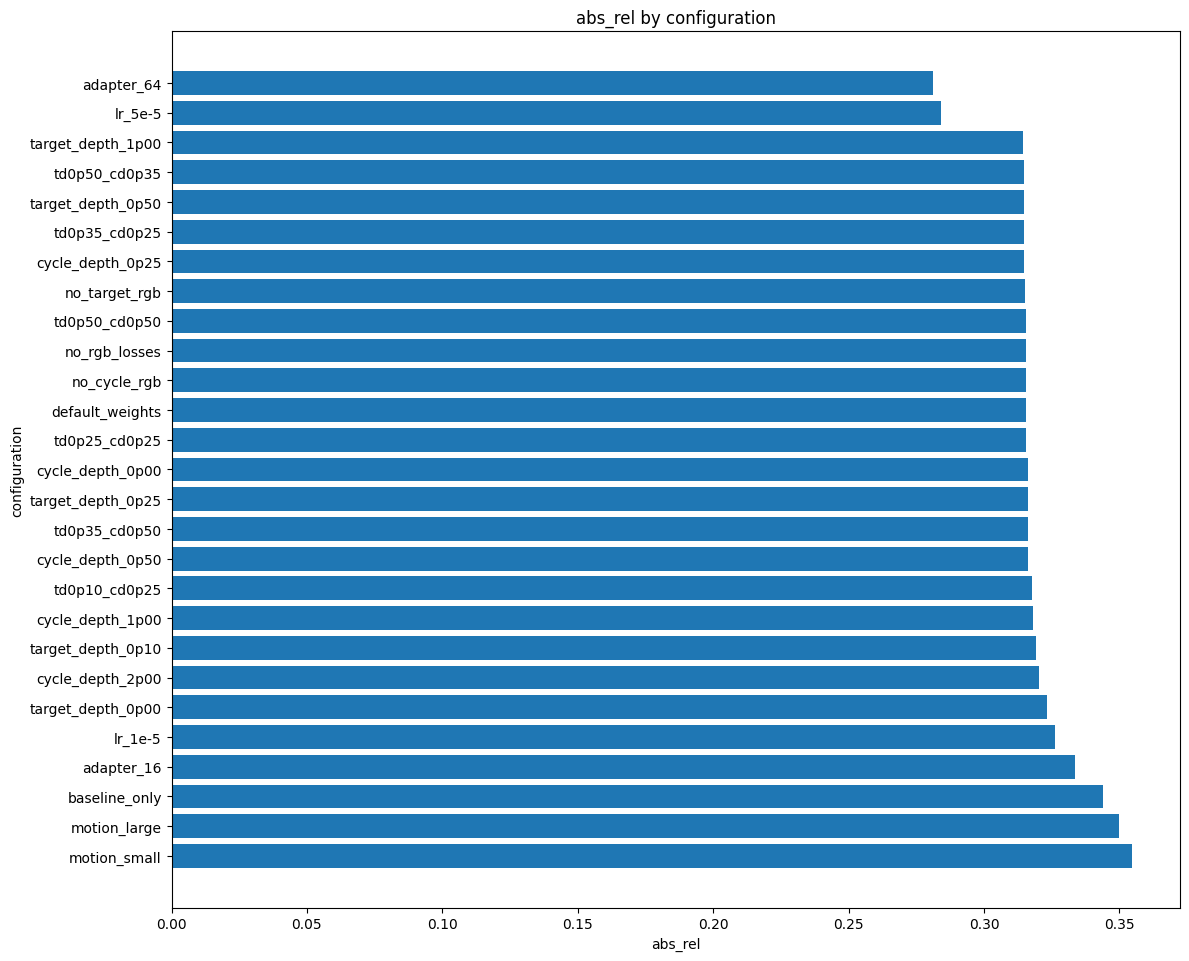

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/abs_rel_by_config.png


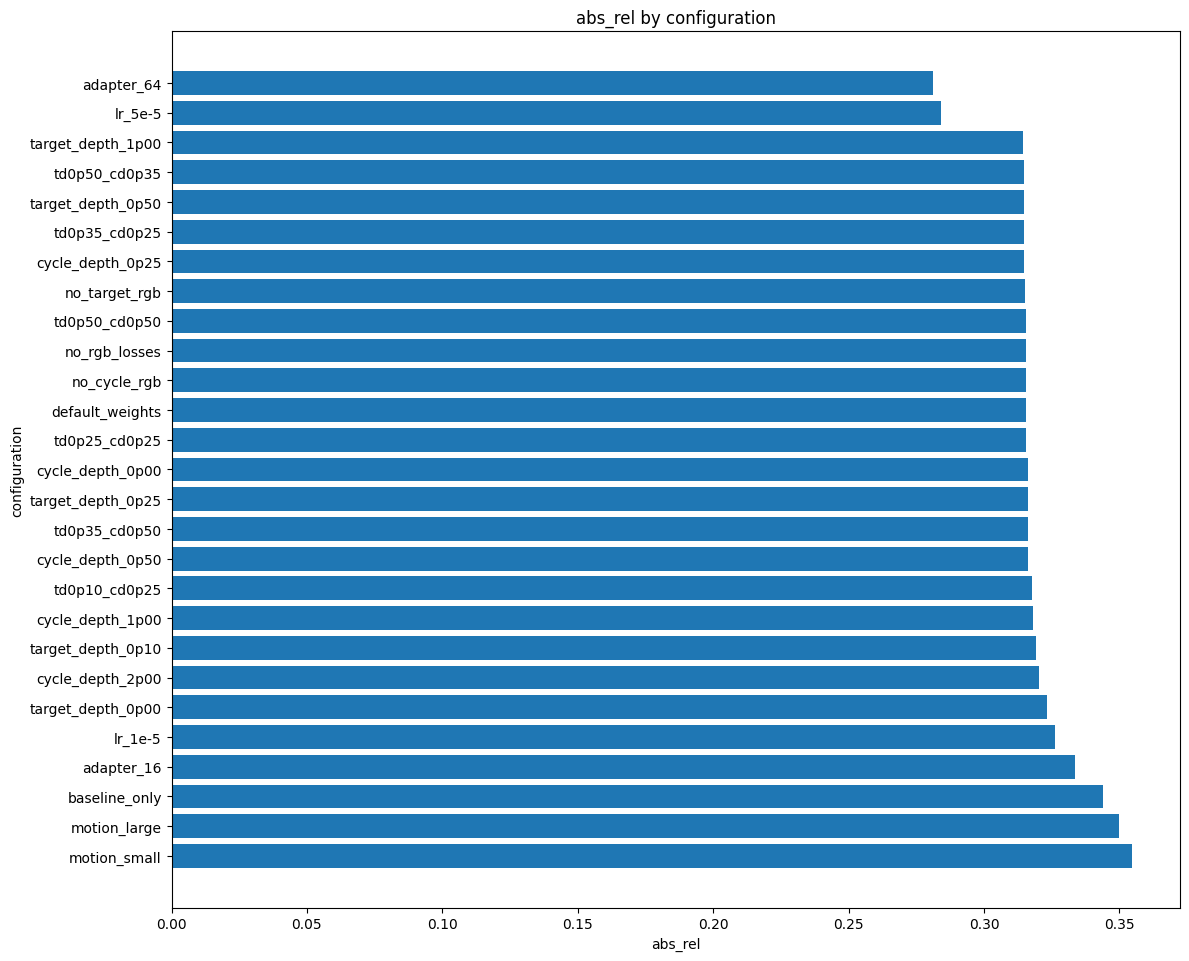

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/abs_rel_by_config.png


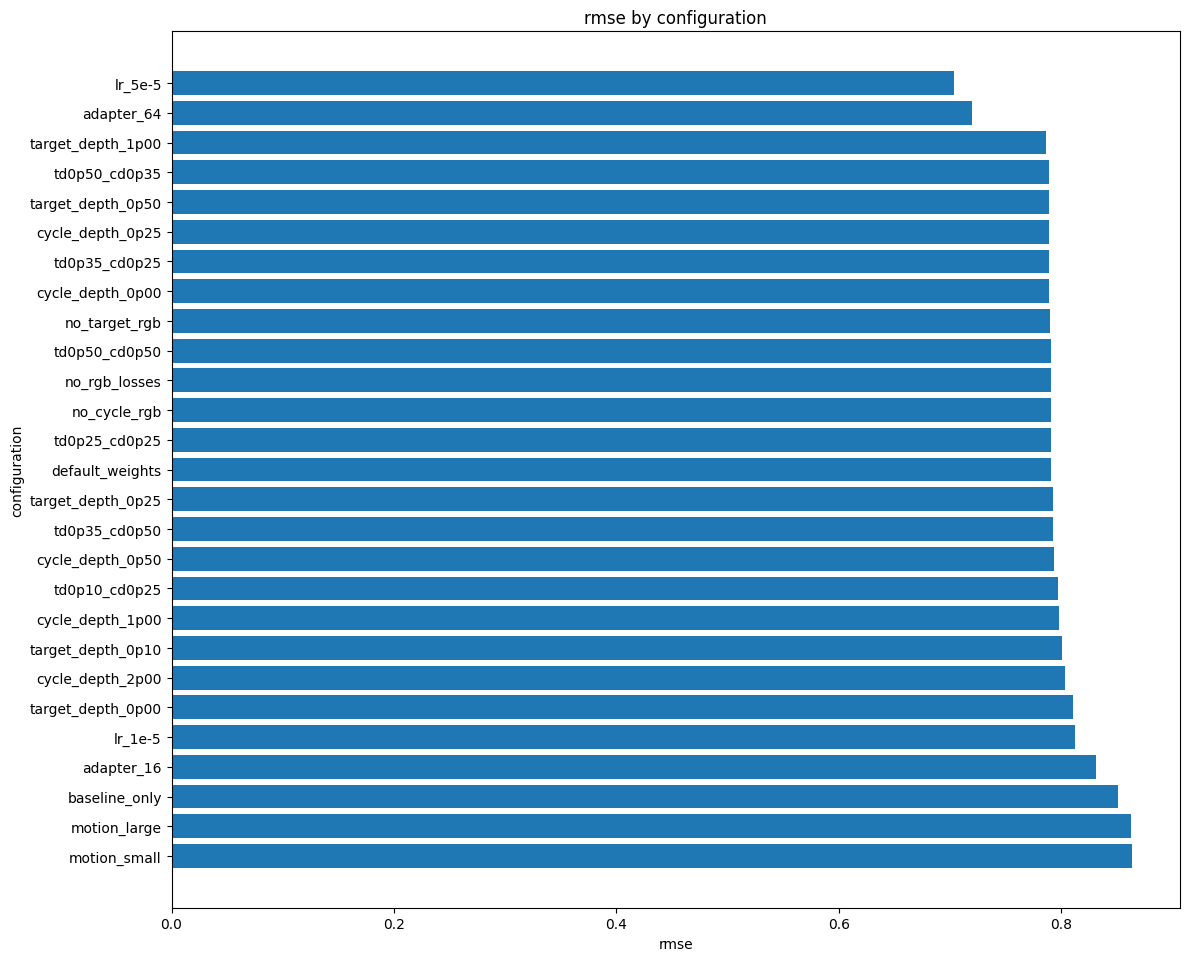

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/rmse_by_config.png


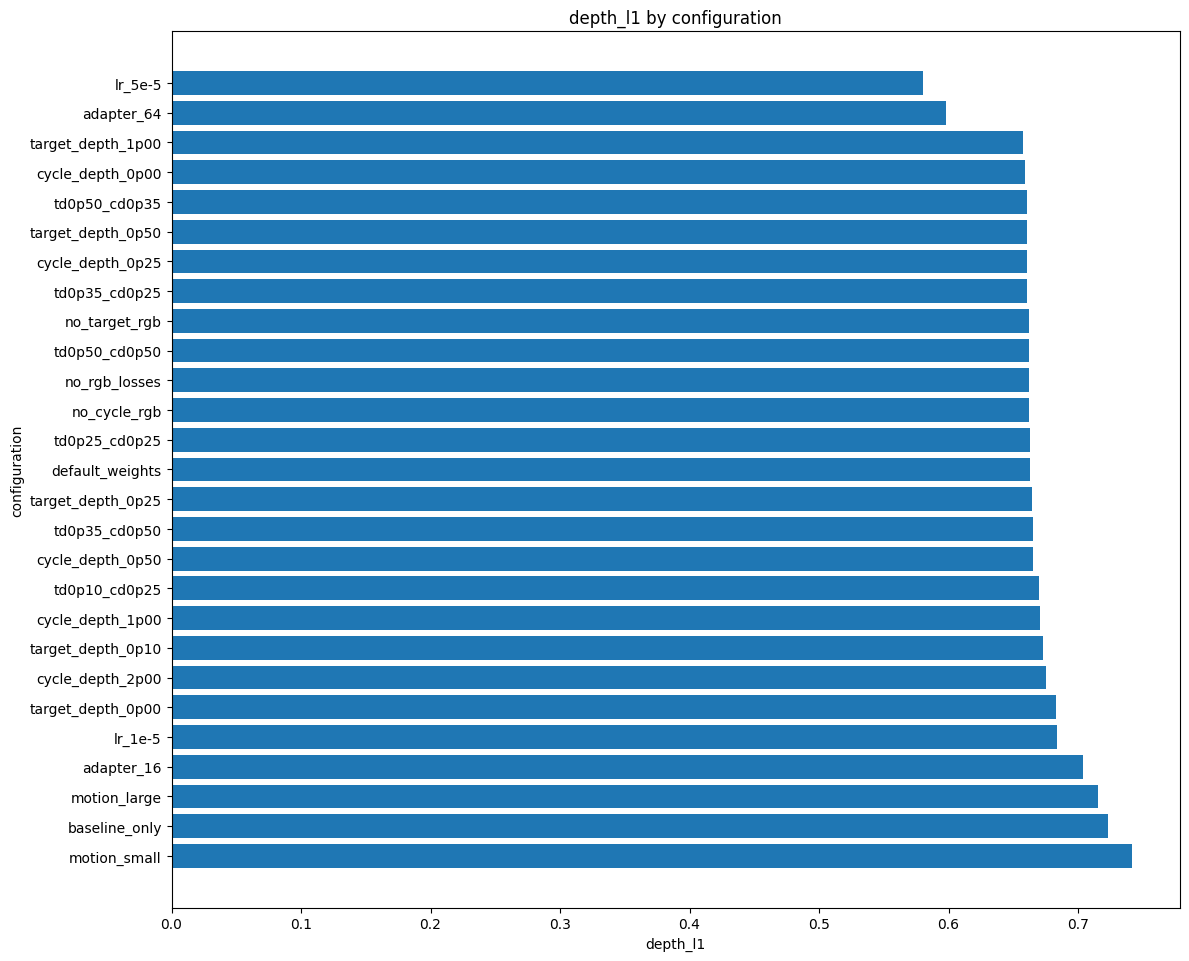

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/depth_l1_by_config.png


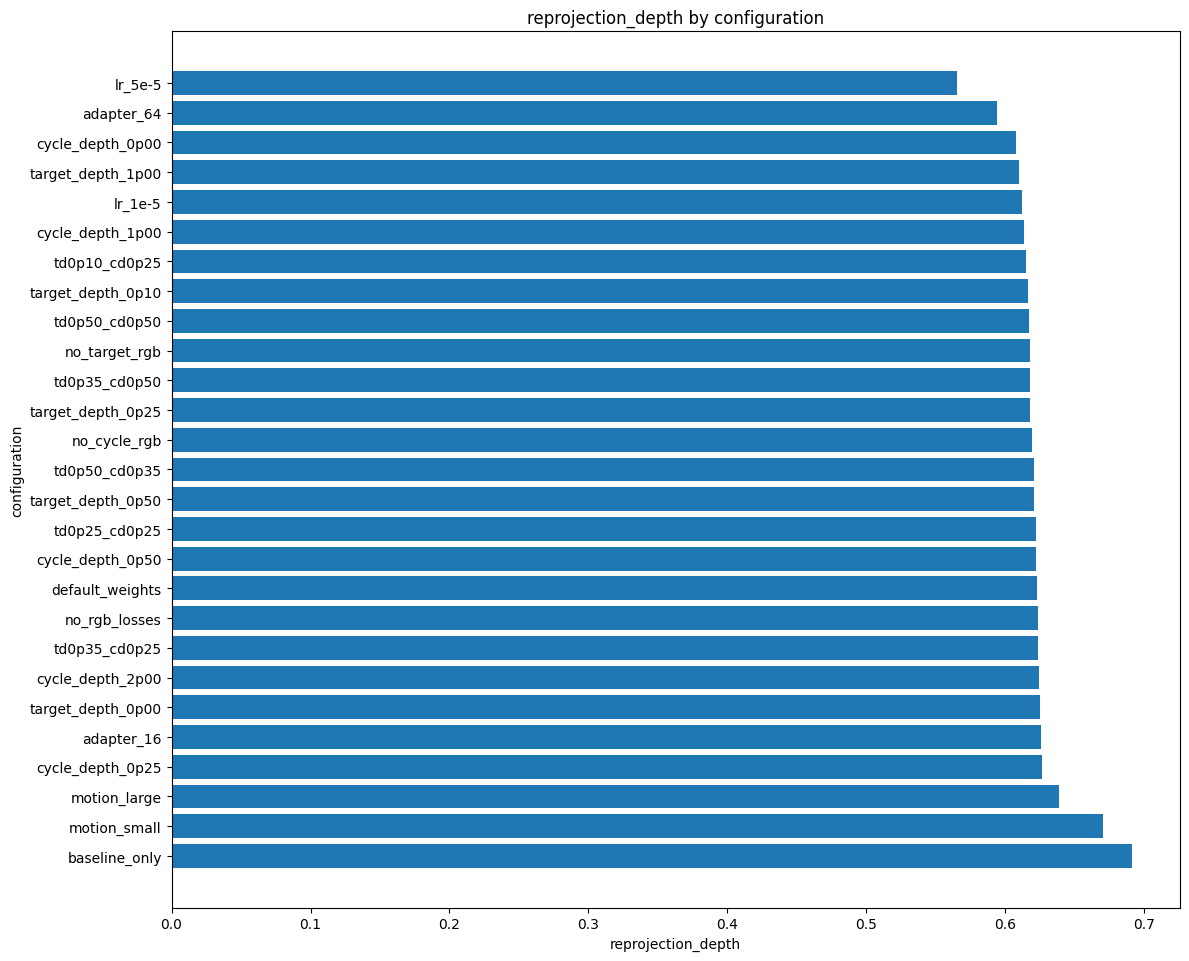

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/reprojection_depth_by_config.png


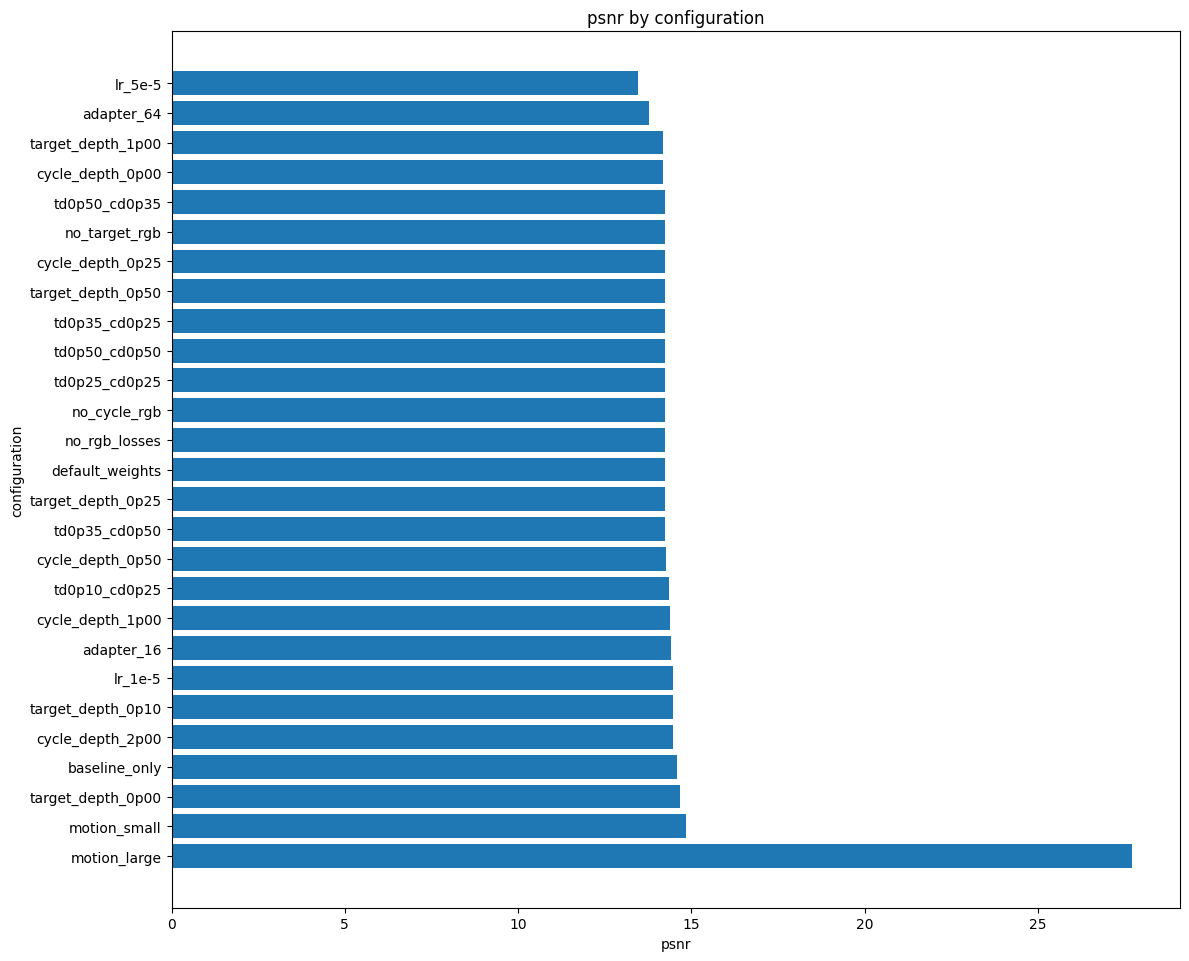

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/psnr_by_config.png


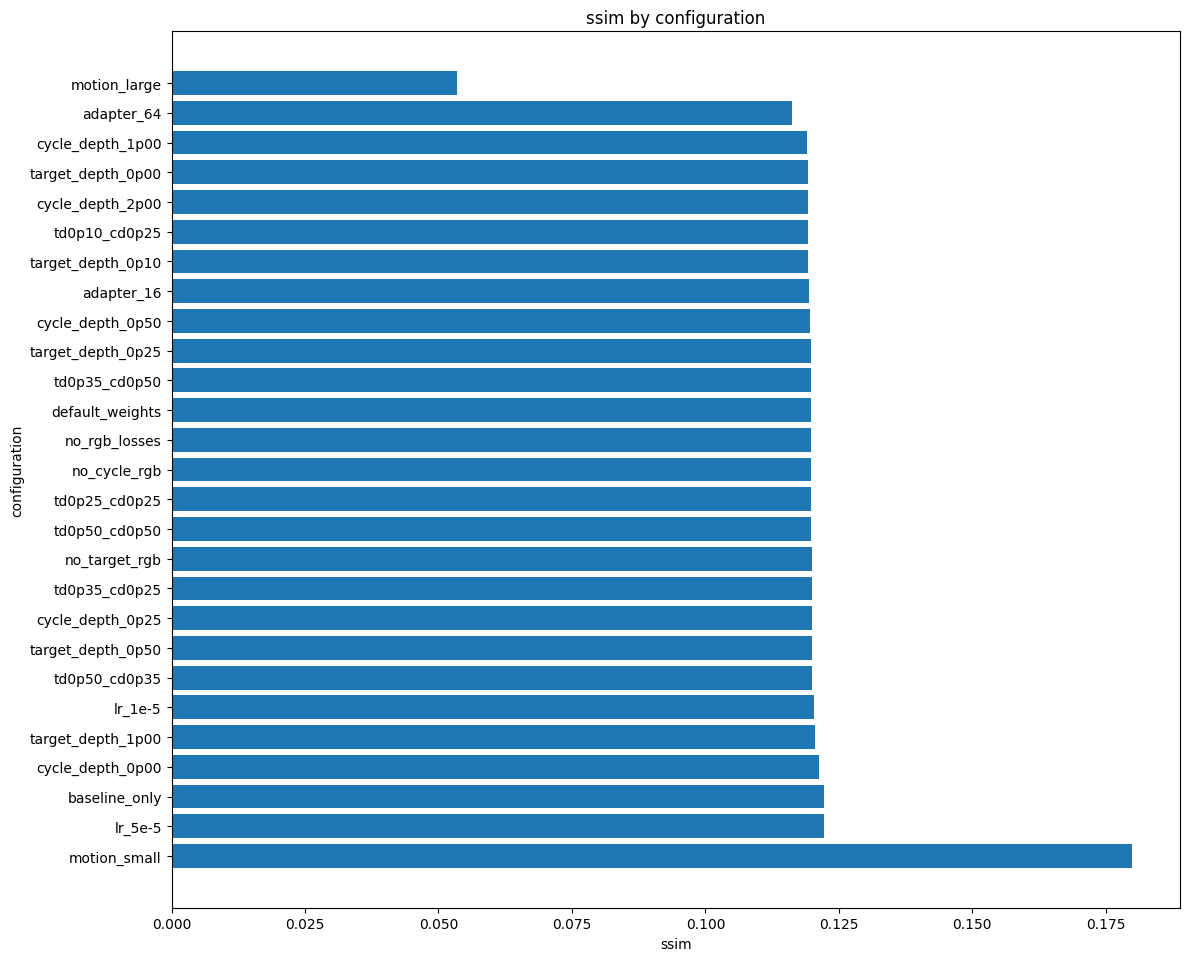

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/ssim_by_config.png


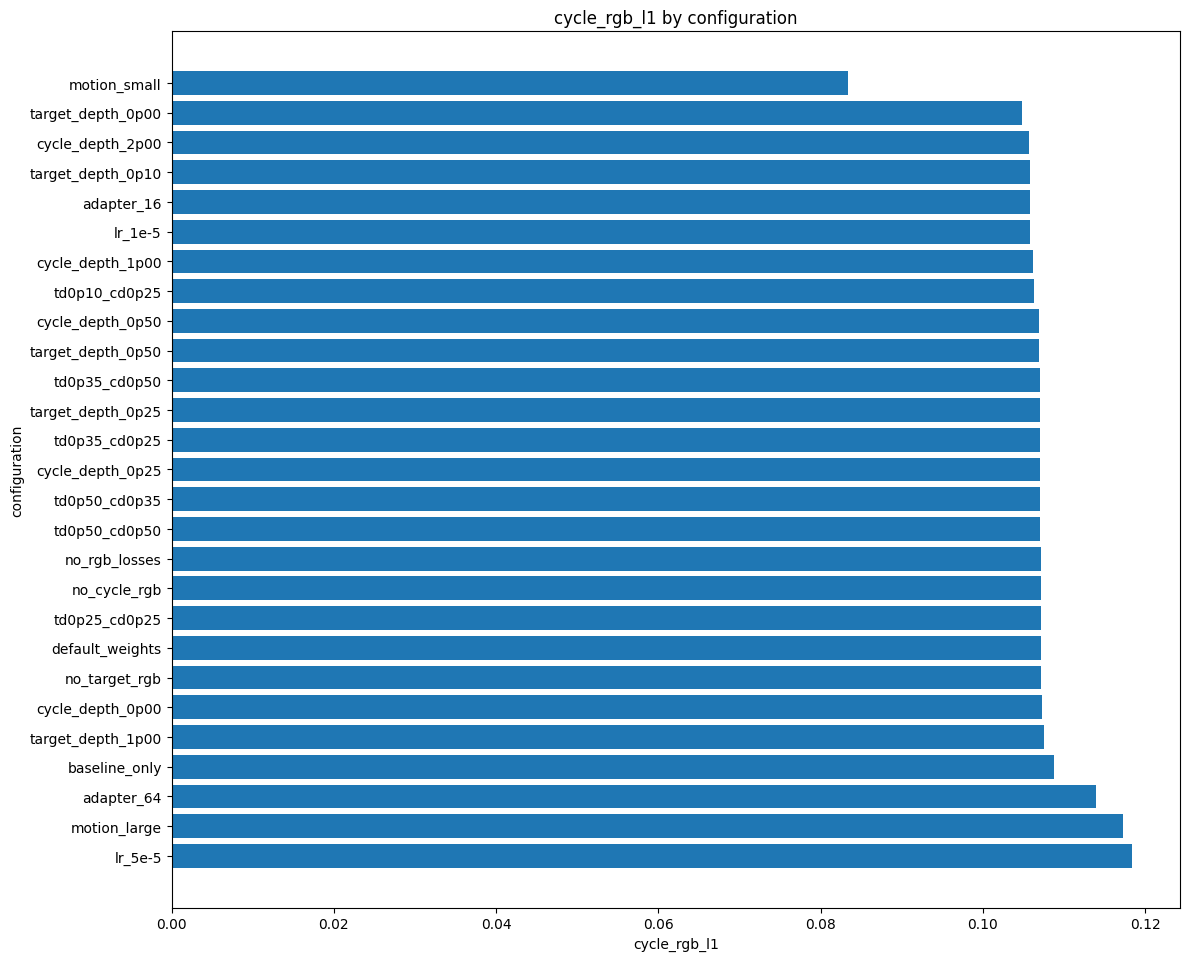

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/cycle_rgb_l1_by_config.png


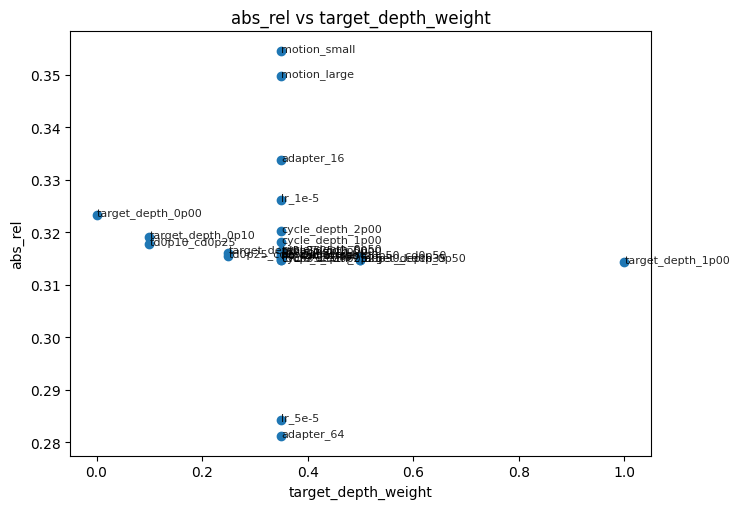

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/abs_rel_vs_target_depth_weight.png


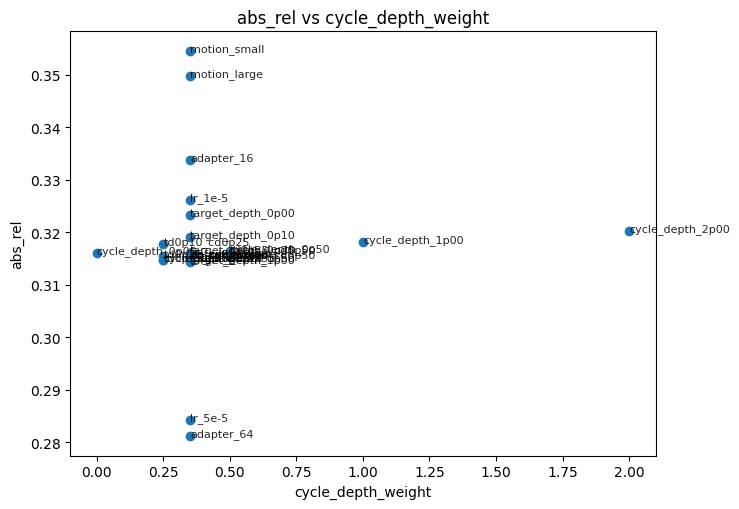

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/abs_rel_vs_cycle_depth_weight.png


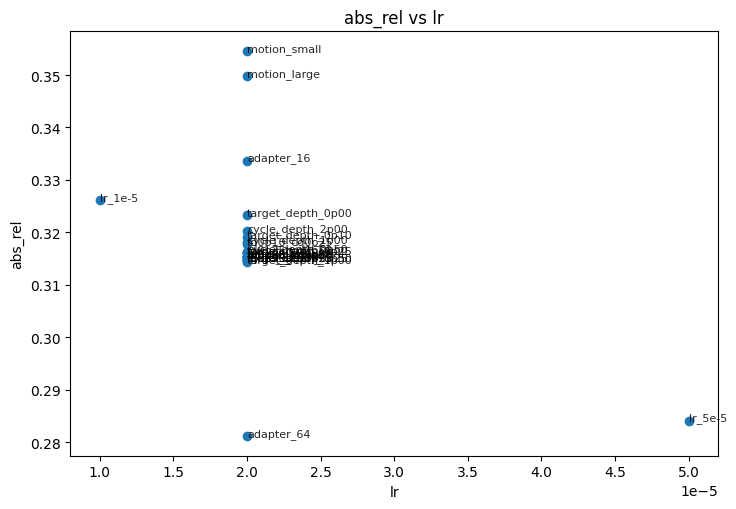

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/abs_rel_vs_lr.png


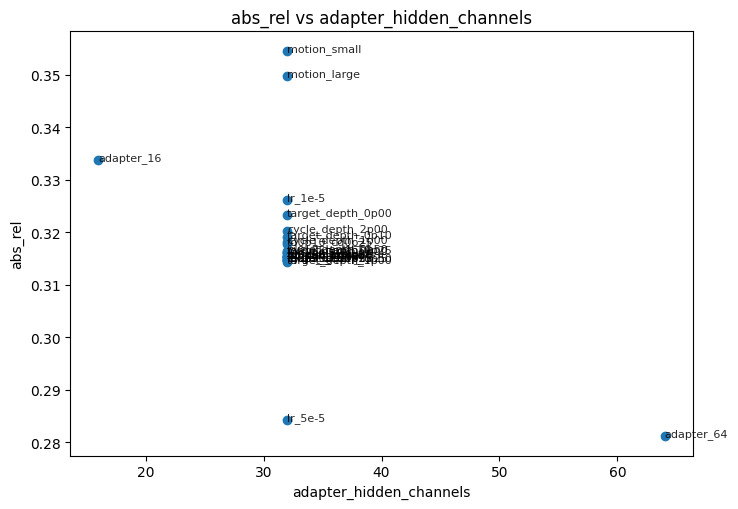

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/abs_rel_vs_adapter_hidden_channels.png


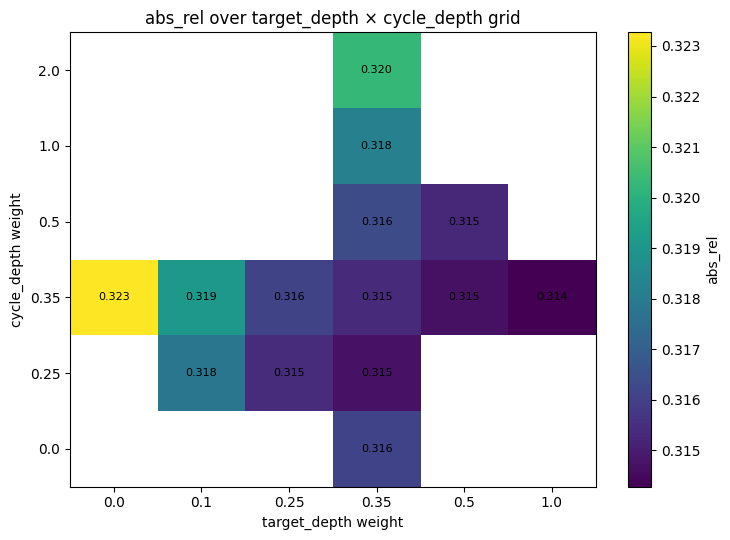

Saved: /kaggle/working/eaglevision_ablation_runs/metrics/plots/abs_rel_depth_weight_grid_heatmap.png
Total plots saved: 13


In [21]:
# =========================
# PLOTS
# =========================

import matplotlib.pyplot as plt

print_header("Generating plots")

plots_dir = ensure_dir(metrics_dir / "plots")

plot_df = ok_df.copy()

def save_bar_metric(df, metric):
    if metric not in df.columns or df.empty:
        return None

    ascending = metric not in HIGHER_IS_BETTER
    tmp = df.sort_values(metric, ascending=ascending).copy()

    plt.figure(figsize=(12, max(4, 0.36 * len(tmp))))
    plt.barh(tmp["name"], tmp[metric])
    plt.xlabel(metric)
    plt.ylabel("configuration")
    plt.title(f"{metric} by configuration")
    if ascending:
        plt.gca().invert_yaxis()
    plt.tight_layout()

    out = plots_dir / f"{metric}_by_config.png"
    plt.savefig(out, dpi=180)
    plt.show()
    print(f"Saved: {out}")
    return out

def save_scatter_metric(df, x_col, y_col, title=None):
    if x_col not in df.columns or y_col not in df.columns:
        return None

    tmp = df[[x_col, y_col, "name", "kind"]].dropna().copy()
    tmp = tmp[tmp["kind"] == "ablation"] if "kind" in tmp.columns else tmp

    if tmp.empty or tmp[x_col].nunique() <= 1:
        return None

    plt.figure(figsize=(7.5, 5.2))
    plt.scatter(tmp[x_col], tmp[y_col])
    for _, row in tmp.iterrows():
        plt.annotate(str(row["name"]), (row[x_col], row[y_col]), fontsize=8, alpha=0.85)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title or f"{y_col} vs {x_col}")
    plt.tight_layout()

    safe_x = x_col.replace("/", "_")
    safe_y = y_col.replace("/", "_")
    out = plots_dir / f"{safe_y}_vs_{safe_x}.png"
    plt.savefig(out, dpi=180)
    plt.show()
    print(f"Saved: {out}")
    return out

plot_files = []

for metric in [primary_metric, "abs_rel", "rmse", "depth_l1", "reprojection_depth", "psnr", "ssim", "cycle_rgb_l1"]:
    if metric in plot_df.columns:
        out = save_bar_metric(plot_df, metric)
        if out:
            plot_files.append(str(out))

for x_col in ["target_depth_weight", "cycle_depth_weight", "lr", "adapter_hidden_channels"]:
    out = save_scatter_metric(plot_df, x_col, primary_metric)
    if out:
        plot_files.append(str(out))


def save_depth_grid_heatmap(df, metric):
    required = {"target_depth_weight", "cycle_depth_weight", metric, "group"}
    if not required.issubset(df.columns):
        return None

    tmp = df[df["group"].isin(["depth_weight_grid", "default", "target_depth", "cycle_depth"])].copy()
    tmp = tmp.dropna(subset=["target_depth_weight", "cycle_depth_weight", metric])
    tmp = tmp.drop_duplicates(subset=["target_depth_weight", "cycle_depth_weight"], keep="first")

    if tmp.empty or tmp["target_depth_weight"].nunique() < 2 or tmp["cycle_depth_weight"].nunique() < 2:
        return None

    pivot = tmp.pivot_table(
        index="cycle_depth_weight",
        columns="target_depth_weight",
        values=metric,
        aggfunc="mean",
    ).sort_index(ascending=True).sort_index(axis=1, ascending=True)

    plt.figure(figsize=(7.5, 5.5))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
    plt.yticks(range(len(pivot.index)), [str(y) for y in pivot.index])
    plt.xlabel("target_depth weight")
    plt.ylabel("cycle_depth weight")
    plt.title(f"{metric} over target_depth × cycle_depth grid")
    plt.colorbar(label=metric)

    for i, y in enumerate(pivot.index):
        for j, x in enumerate(pivot.columns):
            val = pivot.loc[y, x]
            if pd.notna(val):
                plt.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    out = plots_dir / f"{metric}_depth_weight_grid_heatmap.png"
    plt.savefig(out, dpi=180)
    plt.show()
    print(f"Saved: {out}")
    return out


heatmap_out = save_depth_grid_heatmap(plot_df, primary_metric)
if heatmap_out:
    plot_files.append(str(heatmap_out))

with open(metrics_dir / "plot_files.json", "w", encoding="utf-8") as f:
    json.dump(plot_files, f, indent=2)

print(f"Total plots saved: {len(plot_files)}")


## 15. Auto-generate final analysis report

This cell writes a Markdown report based on the actual results.

The report includes:

- experiment setup
- best configuration
- ranked table
- baseline vs default comparison
- per-ablation-group observations
- failed run summary
- paper-ready conclusion paragraph


In [22]:
# =========================
# AUTO-GENERATED REPORT
# =========================

print_header("Generating final analysis report")

def fmt_value(x):
    try:
        if pd.isna(x):
            return "NA"
    except Exception:
        pass
    if isinstance(x, float):
        return f"{x:.6f}"
    return str(x)

def direction(metric):
    return "higher is better" if metric in HIGHER_IS_BETTER else "lower is better"

def best_for_metric(df, metric):
    if metric not in df.columns or df.empty:
        return None
    ascending = metric not in HIGHER_IS_BETTER
    return df.sort_values(metric, ascending=ascending).iloc[0]

def summarize_group(group_name):
    sub = rank_df[rank_df.get("group", "") == group_name].copy()
    if sub.empty:
        return f"No successful `{group_name}` runs were available."
    best = sub.iloc[0]
    return (
        f"Best `{group_name}` run by mean rank was `{best['name']}` "
        f"with `{primary_metric}={fmt_value(best[primary_metric])}`."
    )

def failed_run_summary(df):
    if "status" not in df.columns:
        return "No status column was available."
    failed = df[df["status"] != "ok"].copy()
    if failed.empty:
        return "No failed or incomplete runs were recorded."
    lines = [f"{len(failed)} failed/non-complete run(s) were recorded:"]
    for _, row in failed.iterrows():
        log_ref = row.get("train_log", None) or row.get("eval_log", None) or "NA"
        lines.append(f"- `{row.get('name', 'unknown')}`: `{row.get('status', 'unknown')}`. Log: `{log_ref}`")
    return "\n".join(lines)

best_row = rank_df.iloc[0]

report_lines = []
report_lines.append("# EagleVision Hyperparameter Ablation Report")
report_lines.append("")
report_lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("")
report_lines.append("## 1. Experimental setup")
report_lines.append("")
report_lines.append(f"- Repository: `{REPO_URL}`")
report_lines.append(f"- Runtime profile: `{RUN_PROFILE}`")
report_lines.append(f"- Ablation preset: `{ABLATION_PRESET}`")
report_lines.append(f"- Device: `{DEVICE}`")
report_lines.append(f"- Encoder: `{ENCODER}`")
report_lines.append(f"- Depth mode/profile: `{DEPTH_MODE}` / `{DEPTH_PROFILE}`")
report_lines.append(f"- Checkpoint path: `{CHECKPOINT_PATH}`")
report_lines.append(f"- Image size: `{IMAGE_SIZE}`")
report_lines.append(f"- Attached-notebook style split: `{TRAIN_SCENE_FRACTION:.2f}` train fraction")
report_lines.append(f"- Scene limit: `{SCENE_LIMIT}`")
report_lines.append(f"- Default loss weights: `{DEFAULT_WEIGHTS}`")
report_lines.append(f"- Epochs: `{EPOCHS}`")
report_lines.append(f"- Max steps per epoch: `{MAX_STEPS_PER_EPOCH}`")
report_lines.append(f"- Max eval batches: `{MAX_EVAL_BATCHES}`")
report_lines.append(f"- Batch size: `{BATCH_SIZE}`")
report_lines.append(f"- Train scenes: `{len(train_scenes)}`")
report_lines.append(f"- Validation scenes: `{len(val_scenes)}`")
report_lines.append(f"- Pairing config: `{PAIRING}`")
report_lines.append("")

if CHECKPOINT_PATH is None:
    report_lines.append("> **Warning:** No pretrained checkpoint was loaded. These results should be treated as pipeline/debug ablations, not final pretrained Depth Anything V2 results.")
    report_lines.append("")

report_lines.append("## 2. Ablation goal")
report_lines.append("")
report_lines.append(
    "The ablation studies how EagleVision's adapter training responds to different loss balances and optimization settings. "
    "The most important tested hyperparameters are the `target_depth` weight and the `cycle_depth` weight, because these directly control the trade-off between metric depth anchoring and round-trip geometric consistency. This notebook follows the attached baseline notebook's data, image-size, pairing, checkpoint, and evaluation setup, while reducing epochs for feasible ablation. The full suite also tests their interaction, RGB-loss dependence, optimizer sensitivity, adapter capacity, and camera-motion robustness."
)
report_lines.append("")
report_lines.append("## 3. Main result")
report_lines.append("")
report_lines.append(
    f"The best configuration by mean metric rank was `{best_row['name']}`. "
    f"Using the primary metric `{primary_metric}` ({direction(primary_metric)}), it achieved `{primary_metric}={fmt_value(best_row[primary_metric])}`."
)
report_lines.append("")
report_lines.append("Top ranked configurations:")
report_lines.append("")
top_cols = [c for c in ["name", "group", primary_metric, "mean_rank", "target_depth_weight", "cycle_depth_weight", "lr", "adapter_hidden_channels"] if c in rank_df.columns]
report_lines.append(rank_df[top_cols].head(10).to_markdown(index=False))
report_lines.append("")
report_lines.append("## 4. Metric-specific best runs")
report_lines.append("")
for metric in available_lower + available_higher:
    row = best_for_metric(ok_df, metric)
    if row is not None:
        report_lines.append(f"- Best `{metric}` ({direction(metric)}): `{row['name']}` = `{fmt_value(row[metric])}`")
report_lines.append("")
report_lines.append("## 5. Ablation-group observations")
report_lines.append("")
for group_name in ["target_depth", "cycle_depth", "depth_weight_grid", "learning_rate", "adapter_capacity", "rgb_loss", "motion_range"]:
    report_lines.append(f"- {summarize_group(group_name)}")
report_lines.append("")
report_lines.append("## 6. Baseline comparison")
report_lines.append("")
if "baseline_only" in set(ok_df["name"]) and "default_weights" in set(ok_df["name"]):
    baseline = ok_df[ok_df["name"] == "baseline_only"].iloc[0]
    default = ok_df[ok_df["name"] == "default_weights"].iloc[0]
    report_lines.append("Baseline-only and default adapted model both completed successfully.")
    for metric in [primary_metric, "abs_rel", "rmse", "depth_l1", "reprojection_depth", "psnr", "ssim"]:
        if metric in ok_df.columns:
            delta = default[metric] - baseline[metric]
            report_lines.append(f"- `{metric}`: baseline `{fmt_value(baseline[metric])}`, default `{fmt_value(default[metric])}`, delta `{fmt_value(delta)}`")
else:
    report_lines.append("A full baseline-vs-default comparison could not be computed because one of the two runs did not complete successfully.")
report_lines.append("")
report_lines.append("## 7. Failed or incomplete runs")
report_lines.append("")
report_lines.append(failed_run_summary(results_df))
report_lines.append("")
report_lines.append("## 8. Paper-ready summary")
report_lines.append("")
report_lines.append(
    "The hyperparameter ablation provides empirical justification for the final EagleVision configuration by comparing direct depth anchoring, round-trip depth consistency, optimizer sensitivity, and adapter capacity under a fixed data split and runtime budget. "
    "The target-depth sweep tests whether metric depth supervision is necessary, while the cycle-depth sweep tests whether the round-trip geometry term contributes useful consistency. The depth-weight grid tests whether the best configuration depends on the interaction between these two losses. The RGB-loss and motion-range ablations evaluate robustness beyond the core depth losses. "
    "A strong final configuration should reduce depth errors such as AbsRel/RMSE/Depth-L1 while preserving reasonable reconstruction metrics such as cycle RGB L1, PSNR, and SSIM. "
    "If the default or nearby configuration ranks best, it supports the selected balance between metric accuracy and geometric consistency. "
    "If a stronger target-depth or cycle-depth setting wins, the paper should report that the original default was improved through ablation and use the best validation configuration as the final setting."
)
report_lines.append("")
report_lines.append("## 9. Generated files")
report_lines.append("")
report_lines.append(f"- Results CSV: `{csv_path}`")
report_lines.append(f"- Results JSON: `{json_path}`")
report_lines.append(f"- Excel workbook: `{xlsx_path}`")
report_lines.append(f"- Ranked results: `{ranked_path}`")
report_lines.append(f"- Plots directory: `{plots_dir}`")
report_lines.append(f"- Scene discovery report: `{EXPERIMENT_ROOT / 'scene_discovery_report.csv'}`")
report_lines.append(f"- Fixed split: `{EXPERIMENT_ROOT / 'fixed_split.json'}`")

report_text = "\n".join(report_lines)
report_path = metrics_dir / "analysis_report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)
print(f"\nSaved report: {report_path}")



Generating final analysis report
# EagleVision Hyperparameter Ablation Report

Generated: 2026-05-02 07:09:06

## 1. Experimental setup

- Repository: `https://github.com/alooboii/EagleVision.git`
- Runtime profile: `paper_reduced`
- Ablation preset: `paper_full`
- Device: `cuda`
- Encoder: `vits`
- Depth mode/profile: `metric` / `hypersim`
- Checkpoint path: `/kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth`
- Image size: `[192, 288]`
- Attached-notebook style split: `0.90` train fraction
- Scene limit: `200`
- Default loss weights: `{'target_rgb': 1.0, 'cycle_rgb': 1.0, 'cycle_depth': 0.35, 'target_depth': 0.35}`
- Epochs: `5`
- Max steps per epoch: `300`
- Max eval batches: `780`
- Batch size: `1`
- Train scenes: `180`
- Validation scenes: `20`
- Pairing config: `{'min_translation_m': 0.02, 'max_translation_m': 0.3, 'min_rotation_deg': 0.8, 'max_rotation_deg': 8.0, 'max_index_gap': 10, 'frame_stride': 2, 'max_frames_per_s

## 16. Package final artifacts

This creates a zip file containing the numerical results, configs, report, plots, and logs.

Download this zip from Kaggle after the run.


In [ ]:
# =========================
# ZIP ARTIFACTS
# =========================

print_header("Packaging final artifacts")

artifact_zip = WORK_DIR / "eaglevision_ablation_artifacts.zip"

if artifact_zip.exists():
    artifact_zip.unlink()

# Archive the experiment directory.
shutil.make_archive(str(artifact_zip).replace(".zip", ""), "zip", root_dir=EXPERIMENT_ROOT)

print(f"Created artifact zip: {artifact_zip}")
print("Download this zip from the Kaggle output panel.")



Packaging final artifacts


## 17. Final checklist

Before using the results in the paper, verify:

- [ ] `baseline_only` completed or failure is explained.
- [ ] `default_weights` completed.
- [ ] At least 4-5 ablation variants completed.
- [ ] The same train/validation split was used for every run.
- [ ] Failed runs are not hidden.
- [ ] `ablation_results.xlsx` has all numerical results.
- [ ] `analysis_report.md` includes the final best configuration.
- [ ] Plots are inspected for obvious broken/outlier runs.
- [ ] If no pretrained checkpoint was loaded, the report explicitly states this limitation.
